In [1]:
# ============================================================
# 공통 패키지
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro


# ============================================================
# 공통 기본 설정
# ============================================================
rcParams["font.family"] = "Arial"
rcParams["font.sans-serif"] = ["Arial"]
rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"]
})

base_path = "C:\\Users\\Main\\Dropbox\\CNN_LSTM\\수정코드\\"
SAVE_FIG = True
figure_dir = os.path.join(base_path, "Figure_2")

# ============================================================
# 공통 파일 경로
# ------------------------------------------------------------
# Figure 순서를 바꾸더라도 뒤쪽 계산 셀에서 경로 변수가 누락되지 않도록
# 필요한 경로를 공통 셀에서 먼저 정의합니다.
# ============================================================
fitted_case_path = os.path.join(base_path, "fitted_prediction_annual_case.xlsx")
population_path = os.path.join(base_path, "전국미래인구 데이터.xlsx")
observed_path = os.path.join(base_path, "New_data11.xlsx")
observed_file = observed_path
population_file = population_path

# ============================================================
# 공통 함수: 같은 엑셀 파일을 여러 번 실제로 읽지 않기 위한 캐시
# ------------------------------------------------------------
# - 각 Figure 셀의 순서는 그대로 유지
# - 동일 경로/옵션으로 호출된 pd.read_excel은 최초 1회만 읽고 이후 복사본 사용
# ============================================================
_EXCEL_CACHE = {}


def read_excel_cached(path, *args, **kwargs):
    key = (os.fspath(path), repr(args), repr(sorted(kwargs.items())))

    if key not in _EXCEL_CACHE:
        _EXCEL_CACHE[key] = pd.read_excel(path, *args, **kwargs)

    cached = _EXCEL_CACHE[key]

    if isinstance(cached, dict):
        return {sheet: df.copy() for sheet, df in cached.items()}

    return cached.copy()

# ============================================================
# 공통 함수: 2025~2069 Cases만 fitted_prediction_annual_case 파일 값으로 교체
# ------------------------------------------------------------
# - 기존 forecasting_SSP*.xlsx의 p025, p50, p975, Population_60 등은 그대로 유지
# - Cases 컬럼만 아래 엑셀의 연도별 SSP 값으로 교체
# - 사용 기간은 2025~2069로 제한, 2070 값은 사용하지 않음
# ============================================================
CASES_REPLACEMENT_FILE = "fitted_prediction_annual_case.xlsx"
CASES_REPLACEMENT_FILE_ALTERNATIVE = "fitted_prediction_annual_case(1).xlsx"
CASES_REPLACEMENT_SANDBOX_PATH = r"/mnt/data/fitted_prediction_annual_case(1).xlsx"

SCENARIO_CASES_COLUMNS = {
    "SSP1-2.6": "SSP126",
    "SSP2-4.5": "SSP245",
    "SSP3-7.0": "SSP370",
    "SSP5-8.5": "SSP585",
}


def get_cases_replacement_path(base_path):
    """base_path 안의 교체용 엑셀 파일을 우선 찾고, 없으면 업로드 경로를 사용한다."""
    candidate_paths = [
        os.path.join(base_path, CASES_REPLACEMENT_FILE),
        os.path.join(base_path, CASES_REPLACEMENT_FILE_ALTERNATIVE),
        CASES_REPLACEMENT_SANDBOX_PATH,
        CASES_REPLACEMENT_FILE,
        CASES_REPLACEMENT_FILE_ALTERNATIVE,
    ]

    for candidate in candidate_paths:
        if candidate and os.path.exists(candidate):
            return candidate

    raise FileNotFoundError(
        "Cases 교체용 파일을 찾을 수 없습니다. "
        f"'{CASES_REPLACEMENT_FILE}' 파일을 base_path 폴더에 넣어주세요."
    )


def replace_cases_2025_2069(temp_df, scenario, base_path, cases_col="Cases"):
    """
    temp_df의 2025~2069 Cases만 fitted_prediction_annual_case 값으로 교체한다.

    Parameters
    ----------
    temp_df : pd.DataFrame
        forecasting_SSP*.xlsx에서 읽어온 데이터
    scenario : str
        예: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    base_path : str
        기존 코드에서 사용하는 데이터 폴더
    cases_col : str
        교체 대상 컬럼. 기본값은 Cases
    """
    temp_df = temp_df.copy()

    if scenario not in SCENARIO_CASES_COLUMNS:
        raise ValueError(f"지원하지 않는 시나리오입니다: {scenario}")

    year_col = "Year" if "Year" in temp_df.columns else "year" if "year" in temp_df.columns else None
    if year_col is None:
        raise ValueError("forecasting SSP 파일에 'Year' 또는 'year' 컬럼이 필요합니다.")

    if cases_col not in temp_df.columns:
        raise ValueError(f"forecasting SSP 파일에 '{cases_col}' 컬럼이 필요합니다.")

    replacement_path = get_cases_replacement_path(base_path)
    replacement_df = read_excel_cached(replacement_path)

    scenario_col = SCENARIO_CASES_COLUMNS[scenario]
    required_cols = ["Year", scenario_col]
    missing_cols = [col for col in required_cols if col not in replacement_df.columns]
    if missing_cols:
        raise ValueError(
            "Cases 교체용 파일에 필요한 컬럼이 없습니다: " + ", ".join(missing_cols)
        )

    replacement_df = replacement_df[required_cols].copy()
    replacement_df["Year"] = pd.to_numeric(replacement_df["Year"], errors="coerce").astype("Int64")
    replacement_df[scenario_col] = pd.to_numeric(replacement_df[scenario_col], errors="coerce")

    replacement_df = replacement_df[
        (replacement_df["Year"] >= 2025) &
        (replacement_df["Year"] <= 2069)
    ].copy()

    replacement_df = replacement_df.rename(columns={scenario_col: "Cases_replacement"})

    temp_df[year_col] = pd.to_numeric(temp_df[year_col], errors="coerce").astype("Int64")
    # Cases 컬럼은 실수형으로 맞춰 교체 시 dtype 경고가 나지 않도록 한다.
    temp_df[cases_col] = pd.to_numeric(temp_df[cases_col], errors="coerce").astype(float)

    merged = temp_df.merge(replacement_df, left_on=year_col, right_on="Year", how="left")

    replace_mask = (
        (merged[year_col] >= 2025) &
        (merged[year_col] <= 2069) &
        (merged["Cases_replacement"].notna())
    )

    merged.loc[replace_mask, cases_col] = merged.loc[replace_mask, "Cases_replacement"]

    drop_cols = ["Cases_replacement"]

    # merge 방식에 따라 오른쪽 replacement 파일의 Year 컬럼명이 달라질 수 있으므로 정리한다.
    if "Year_y" in merged.columns:
        drop_cols.append("Year_y")
    elif year_col != "Year" and "Year" in merged.columns:
        drop_cols.append("Year")

    merged = merged.drop(columns=[col for col in drop_cols if col in merged.columns])

    if "Year_x" in merged.columns:
        merged = merged.rename(columns={"Year_x": year_col})

    return merged



In [2]:
#Figure 2

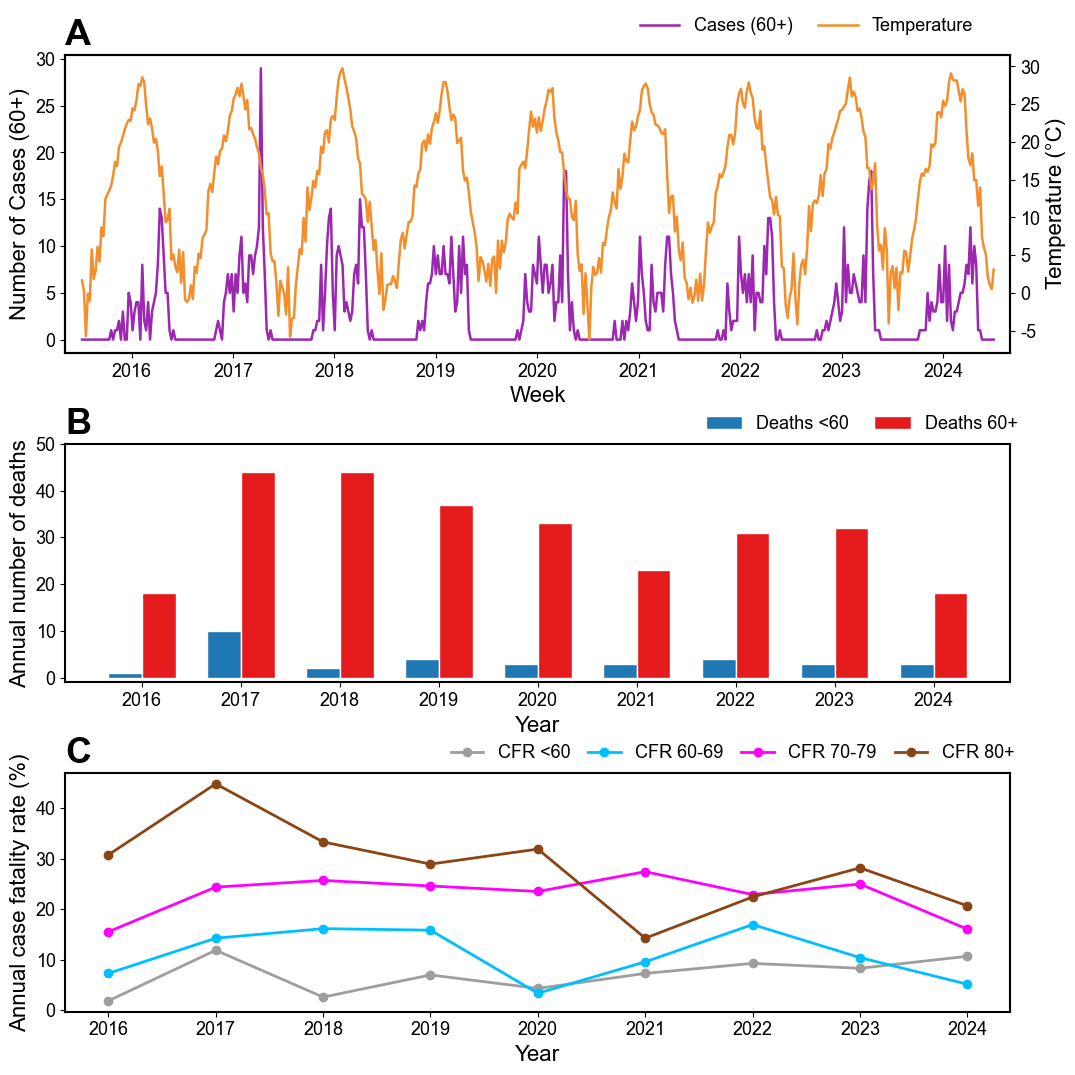

저장 완료: C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Figure 2.tiff

[연간 사망자 및 치사율]
   Year  Deaths_<60  Deaths_60+    CFR_<60  CFR_60_69  CFR_70_79    CFR_80+
0  2016           1          18   1.886792   7.317073  15.555556  30.769231
1  2017          10          44  11.904762  14.285714  24.390244  44.827586
2  2018           2          44   2.631579  16.176471  25.714286  33.333333
3  2019           4          37   7.017544  15.873016  24.615385  28.947368
4  2020           3          33   4.347826   3.389831  23.529412  31.914894
5  2021           3          23   7.317073   9.615385  27.450980  14.285714
6  2022           4          31   9.302326  16.981132  22.916667  22.448980
7  2023           3          32   8.333333  10.447761  25.000000  28.205128
8  2024           3          18  10.714286   5.172414  16.071429  20.689655


In [3]:
# ============================================================
# Figure 2
# A: New_data12.xlsx에서 Cases_60 + Temperature
# B: SFTS_data.xlsx에서 연령대별 사망자 수 계산 (<60, 60+)
# C: SFTS_data.xlsx에서 연령대별 연간 치명률(annual case fatality rate) 계산 (<60, 60-69, 70-79, 80+)
# ============================================================



# ============================================================
# 0) 파일 경로
# ============================================================
new_data_path = r"C:\Users\Main\Dropbox\CNN_LSTM\수정코드\New_data11.xlsx"
sfts_data_path = r"C:\Users\Main\Dropbox\CNN_LSTM\수정코드\SFTS_data.xlsx"

save_path = r"C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Figure 2.tiff"


# ============================================================
# 1) A용 데이터 불러오기: New_data12.xlsx
# ============================================================
new_df = pd.read_excel(new_data_path)
new_df.columns = new_df.columns.astype(str).str.strip()

new_df = new_df[(new_df["Year"] >= 2016) & (new_df["Year"] <= 2024)].copy()

new_df["Date"] = pd.to_datetime(
    new_df["Year"].astype(str) + new_df["Week"].astype(str).str.zfill(2) + "1",
    format="%G%V%u",
    errors="coerce"
)

new_df = new_df.sort_values(["Year", "Week"]).reset_index(drop=True)


# ============================================================
# 2) B, C용 데이터 불러오기: SFTS_data.xlsx
# ============================================================
sfts = pd.read_excel(sfts_data_path)
sfts.columns = sfts.columns.astype(str).str.strip()

sfts = sfts[(sfts["신고일 연도"] >= 2016) & (sfts["신고일 연도"] <= 2024)].copy()

sfts["연령"] = pd.to_numeric(sfts["연령"], errors="coerce")
sfts["Year"] = pd.to_numeric(sfts["신고일 연도"], errors="coerce")

sfts = sfts.dropna(subset=["연령", "Year"]).copy()
sfts["Year"] = sfts["Year"].astype(int)


# ============================================================
# 3) 연령대 및 사망 여부 생성
# ============================================================
def make_age_group_4(age):
    if age < 60:
        return "<60"
    elif age < 70:
        return "60-69"
    elif age < 80:
        return "70-79"
    else:
        return "80+"


sfts["Age_group_4"] = sfts["연령"].apply(make_age_group_4)
sfts["Age_group_2"] = np.where(sfts["연령"] < 60, "<60", "60+")

sfts["Death_flag"] = (
    sfts["사망여부"]
    .astype(str)
    .str.strip()
    .eq("사망")
    .astype(int)
)


# ============================================================
# 4) B: 연간 사망자 수 계산 (<60, 60+)
# ============================================================
yearly_deaths_b = (
    sfts
    .groupby(["Year", "Age_group_2"])["Death_flag"]
    .sum()
    .reset_index()
)

yearly_deaths_b = (
    yearly_deaths_b
    .pivot(index="Year", columns="Age_group_2", values="Death_flag")
    .fillna(0)
    .reset_index()
)

for col in ["<60", "60+"]:
    if col not in yearly_deaths_b.columns:
        yearly_deaths_b[col] = 0

yearly_deaths_b = yearly_deaths_b.rename(columns={
    "<60": "Deaths_<60",
    "60+": "Deaths_60+"
})


# ============================================================
# 5) C: 연간 치사율 계산
# ============================================================
yearly_cases_c = (
    sfts
    .groupby(["Year", "Age_group_4"])
    .size()
    .reset_index(name="Cases")
)

yearly_deaths_c = (
    sfts
    .groupby(["Year", "Age_group_4"])["Death_flag"]
    .sum()
    .reset_index(name="Deaths")
)

yearly_cfr = yearly_cases_c.merge(
    yearly_deaths_c,
    on=["Year", "Age_group_4"],
    how="left"
)

yearly_cfr["Deaths"] = yearly_cfr["Deaths"].fillna(0)

yearly_cfr["CFR"] = np.where(
    yearly_cfr["Cases"] > 0,
    yearly_cfr["Deaths"] / yearly_cfr["Cases"] * 100,
    np.nan
)

yearly_cfr = (
    yearly_cfr
    .pivot(index="Year", columns="Age_group_4", values="CFR")
    .reset_index()
)

for col in ["<60", "60-69", "70-79", "80+"]:
    if col not in yearly_cfr.columns:
        yearly_cfr[col] = np.nan

yearly_cfr = yearly_cfr.rename(columns={
    "<60": "CFR_<60",
    "60-69": "CFR_60_69",
    "70-79": "CFR_70_79",
    "80+": "CFR_80+"
})


# ============================================================
# 6) 연간 데이터 통합
# ============================================================
years = pd.DataFrame({"Year": range(2016, 2025)})

yearly = (
    years
    .merge(
        yearly_deaths_b[["Year", "Deaths_<60", "Deaths_60+"]],
        on="Year",
        how="left"
    )
    .merge(
        yearly_cfr[["Year", "CFR_<60", "CFR_60_69", "CFR_70_79", "CFR_80+"]],
        on="Year",
        how="left"
    )
)

yearly[["Deaths_<60", "Deaths_60+"]] = (
    yearly[["Deaths_<60", "Deaths_60+"]].fillna(0)
)


# ============================================================
# 7) 그림 설정
# ============================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

fig = plt.figure(figsize=(13.5, 11), facecolor="white")

gs = fig.add_gridspec(
    3, 1,
    height_ratios=[1.25, 1, 1]
)

# 오른쪽 범례 공간 + 세로 간격 조정
fig.subplots_adjust(
    left=0.08,
    right=0.78,
    top=0.95,
    bottom=0.08,
    hspace=0.35
)

# A 색상
purple = "#9c27b0"
orange = "#f28e2b"

# B, C 공통 색상
color_under60 = "#1f77b4"
color_60plus = "#e41a1c"

cfr_colors = {
    "<60": "#9E9E9E",    # 회색
    "60-69": "#00BFFF",  # 밝은 하늘색
    "70-79": "#FF00FF",  # 선명한 마젠타
    "80+": "#8B4513"     # 짙은 갈색
}

# ============================================================
# 8) A: Weekly Cases_60 + Temperature
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("white")

l1, = ax1.plot(
    new_df["Date"],
    new_df["Cases_60"],
    color=purple,
    linewidth=1.8,
    label="Cases (60+)"
)

ax1.set_ylabel("Number of Cases (60+)", fontsize=16)
ax1.set_xlabel("Week", fontsize=16)
ax1.tick_params(axis="both", labelsize=13)

ax1b = ax1.twinx()

l2, = ax1b.plot(
    new_df["Date"],
    new_df["tem"],
    color=orange,
    linewidth=1.8,
    label="Temperature"
)

ax1b.set_ylabel("Temperature (°C)", fontsize=16)
ax1b.tick_params(axis="y", labelsize=13)

# ------------------------------------------------------------
# A x축: 매년 7월 기준 tick, 라벨은 연도만 표시
# ------------------------------------------------------------
tick_years = range(2016, 2025)
tick_dates = pd.to_datetime([f"{y}-07-01" for y in tick_years])

ax1.set_xticks(tick_dates)
ax1.set_xticklabels([str(y) for y in tick_years], rotation=0, fontsize=13)

# ------------------------------------------------------------
# A x축 양쪽 여백
# ------------------------------------------------------------
ax1.set_xlim(
    new_df["Date"].min() - pd.Timedelta(days=60),
    new_df["Date"].max() + pd.Timedelta(days=60)
)

# ------------------------------------------------------------
# A 범례: 그림 밖 오른쪽 위, 한 줄
# ------------------------------------------------------------
leg1 = ax1.legend(
    [l1, l2],
    ["Cases (60+)", "Temperature"],
    loc="upper left",
    bbox_to_anchor=(0.6, 1.15),
    ncol=2,
    fontsize=13,
    frameon=True,
    handlelength=2.2,
    columnspacing=1.4,
    borderaxespad=0
)

leg1.get_frame().set_facecolor("none")
leg1.get_frame().set_edgecolor("none")
leg1.get_frame().set_alpha(0)

ax1.text(
    0.0, 1.12, "A",
    transform=ax1.transAxes,
    fontsize=26,
    fontweight="bold",
    va="top"
)


# ============================================================
# 9) B: Yearly deaths <60 and 60+
# ============================================================
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor("white")

x = np.arange(len(yearly["Year"]))
width = 0.34

ax2.bar(
    x - width / 2,
    yearly["Deaths_<60"],
    width=width,
    color=color_under60,
    edgecolor="white",
    label="Deaths <60"
)

ax2.bar(
    x + width / 2,
    yearly["Deaths_60+"],
    width=width,
    color=color_60plus,
    edgecolor="white",
    label="Deaths 60+"
)

ax2.set_xticks(x)
ax2.set_xticklabels(yearly["Year"], fontsize=13)
ax2.set_xlabel("Year", fontsize=16)
ax2.set_ylabel("Annual number of deaths", fontsize=16)
ax2.tick_params(axis="y", labelsize=13)

# ------------------------------------------------------------
# B y축: -1부터 보이게 하되, 눈금은 기존처럼 유지
# ------------------------------------------------------------
b_yticks = ax2.get_yticks()
b_yticks = b_yticks[b_yticks >= 0]

ax2.set_ylim(-1, ax2.get_ylim()[1])
ax2.set_yticks(b_yticks)

# ------------------------------------------------------------
# B 범례: 그림 밖 오른쪽 위, 한 줄
# ------------------------------------------------------------
leg2 = ax2.legend(
    loc="upper left",
    bbox_to_anchor=(0.67, 1.15),
    ncol=2,
    fontsize=13,
    frameon=True,
    handlelength=2.0,
    columnspacing=1.4,
    borderaxespad=0
)

leg2.get_frame().set_facecolor("none")
leg2.get_frame().set_edgecolor("none")
leg2.get_frame().set_alpha(0)

ax2.text(
    0.0, 1.15, "B",
    transform=ax2.transAxes,
    fontsize=26,
    fontweight="bold",
    va="top"
)


# ============================================================
# 10) C: Annual case fatality rate by age group
# ============================================================
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor("white")

ax3.plot(
    yearly["Year"],
    yearly["CFR_<60"],
    marker="o",
    linewidth=2.0,
    color=cfr_colors["<60"],
    label="CFR <60"
)

ax3.plot(
    yearly["Year"],
    yearly["CFR_60_69"],
    marker="o",
    linewidth=2.0,
    color=cfr_colors["60-69"],
    label="CFR 60-69"
)

ax3.plot(
    yearly["Year"],
    yearly["CFR_70_79"],
    marker="o",
    linewidth=2.0,
    color=cfr_colors["70-79"],
    label="CFR 70-79"
)

ax3.plot(
    yearly["Year"],
    yearly["CFR_80+"],
    marker="o",
    linewidth=2.0,
    color=cfr_colors["80+"],
    label="CFR 80+"
)

ax3.set_xlabel("Year", fontsize=16)
ax3.set_ylabel("Annual case fatality rate (%)", fontsize=16)
ax3.set_xticks(yearly["Year"])
ax3.tick_params(axis="both", labelsize=13)

# ------------------------------------------------------------
# C 범례: 그림 밖 오른쪽 위, 한 줄
# ------------------------------------------------------------
leg3 = ax3.legend(
    loc="upper left",
    bbox_to_anchor=(0.4, 1.15),
    ncol=4,
    fontsize=13,
    frameon=True,
    handlelength=1.8,
    columnspacing=1.0,
    borderaxespad=0
)

leg3.get_frame().set_facecolor("none")
leg3.get_frame().set_edgecolor("none")
leg3.get_frame().set_alpha(0)

ax3.text(
    0.0, 1.15, "C",
    transform=ax3.transAxes,
    fontsize=26,
    fontweight="bold",
    va="top"
)


# ============================================================
# 11) 축 테두리 정리
# ============================================================
for ax in [ax1, ax1b, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")


# ============================================================
# 12) 저장
# ============================================================
fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"저장 완료: {save_path}")


# ============================================================
# 13) 계산값 확인용 출력
# ============================================================
print("\n[연간 사망자 및 치사율]")
print(yearly)

## Figure 3. Observed cases and model fitting / DNN bootstrap

C:\Users\Main\AppData\Local\Temp\ipykernel_13180\2159137828.py:746: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


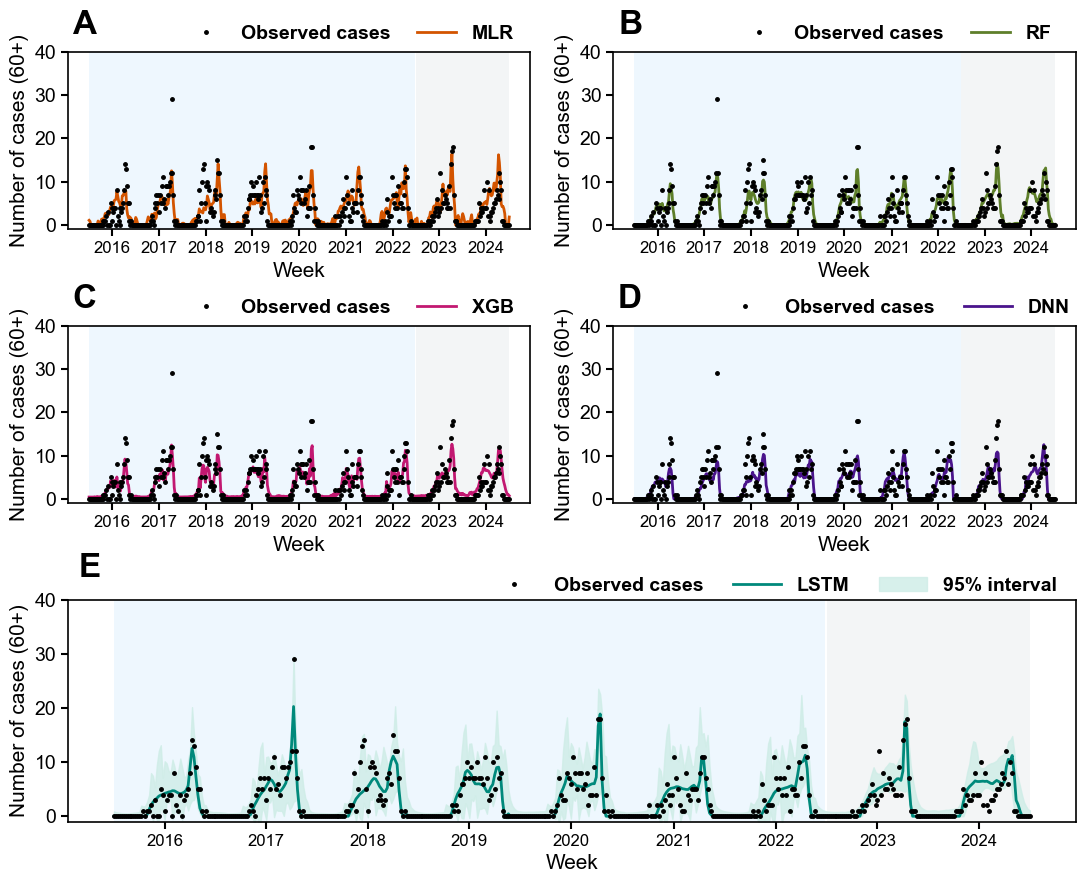

In [4]:
# ============================================================
# 0) 라이브러리 및 기본 설정
# ============================================================

save_name = "Figure3.tiff"
save_path = os.path.join(figure_dir, save_name)


# ============================================================
# 0-1) 시각화 세부 조정값
# ============================================================
BACKGROUND_ALPHA = 0.15     # Train/Test 전체 배경 음영
INTERVAL_ALPHA = 0.82       # E의 Prediction interval shaded
OBS_MARKER_SIZE = 2.5       # Observed cases 점 크기
AXIS_LABEL_SIZE = 15        # 축 제목 글자 크기
XTICK_LABEL_SIZE = 12       # x축 연도 글자 크기
YTICK_LABEL_SIZE = 14       # y축 tick 글자 크기
PANEL_LABEL_SIZE = 24       # A-E 패널 라벨 크기
LEGEND_FONT_SIZE = 14       # 모든 범례 글씨 크기 동일


# ============================================================
# 1) 데이터 불러오기
# ============================================================
data = read_excel_cached(base_path + "New_data11.xlsx")

train_cases = read_excel_cached(
    base_path + "best_valid_result_train.xlsx"
)
test_cases = read_excel_cached(
    base_path + "best_valid_result_test.xlsx"
)

train_ci = read_excel_cached(
    base_path + "DNN_CI_train_result.xlsx"
)
test_ci = read_excel_cached(
    base_path + "DNN_CI_test_result.xlsx"
)

lstm_train_ci = read_excel_cached(
    base_path + "LSTM_CI_train_result.xlsx"
)
lstm_test_ci = read_excel_cached(
    base_path + "LSTM_CI_test_result.xlsx"
)


# ============================================================
# 2) 날짜 생성 함수
# ============================================================
def create_start_date_cases(df):
    df["start_date"] = (
        pd.to_datetime(
            df["Year"].astype(str) + "-1",
            format="%Y-%w"
        )
        + pd.to_timedelta(
            (df["Week"] - 1) * 7,
            unit="D"
        )
    )


# ============================================================
# 3) 관측값 및 예측값 준비
# ============================================================
y_all = data.loc[
    data["Year"].between(2016, 2024),
    ["Year", "Week", "Cases_60"]
].copy()

y_all.index = range(len(y_all))

pred_all = pd.concat(
    [train_cases, test_cases],
    ignore_index=True
)

create_start_date_cases(pred_all)
pred_all.index = range(len(pred_all))


# ============================================================
# 4) DNN / LSTM CI 데이터에 관측값 붙이기
# ============================================================
obs_df = data[
    ["Year", "Week", "Cases_60"]
].copy()


def prepare_ci_with_observed(
    train_df,
    test_df,
    obs_df
):
    train_df = train_df.merge(
        obs_df,
        on=["Year", "Week"],
        how="left"
    )

    test_df = test_df.merge(
        obs_df,
        on=["Year", "Week"],
        how="left"
    )

    create_start_date_cases(train_df)
    create_start_date_cases(test_df)

    train_df.index = range(len(train_df))
    test_df.index = range(len(test_df))

    ci_all = pd.concat(
        [train_df, test_df],
        ignore_index=True
    )

    ci_all.index = range(len(ci_all))

    return train_df, test_df, ci_all


train_ci, test_ci, dnn_ci_all = prepare_ci_with_observed(
    train_ci,
    test_ci,
    obs_df
)

lstm_train_ci, lstm_test_ci, lstm_ci_all = (
    prepare_ci_with_observed(
        lstm_train_ci,
        lstm_test_ci,
        obs_df
    )
)


# ============================================================
# 5) x축 눈금 생성 함수
# ============================================================
def generate_year_center_ticks(df):
    ticks = []
    labels = []

    for year in sorted(df["Year"].unique()):
        if year > 2024:
            continue

        year_data = df[
            df["Year"] == year
        ].copy()

        target_date = pd.to_datetime(
            f"{year}-07-01"
        )

        center_index = (
            (year_data["start_date"] - target_date)
            .abs()
            .idxmin()
        )

        ticks.append(center_index)
        labels.append(str(year))

    return ticks, labels


pred_all_for_ticks = pred_all.merge(
    y_all[
        ["Year", "Week", "Cases_60"]
    ],
    on=["Year", "Week"],
    how="left"
)

xticks_model, xlabels_model = (
    generate_year_center_ticks(
        pred_all_for_ticks
    )
)

xticks_dnn, xlabels_dnn = (
    generate_year_center_ticks(
        dnn_ci_all
    )
)


# ============================================================
# 6) 모델 색상
#    실제 컬럼명은 LR 그대로 사용
#    그림 표시만 MLR로 변경
# ============================================================
model_styles = {
    "LR": {
        "median": "#E67E22",
        "best": "#D35400",
        "ci": "#F8D7B5"
    },
    "RF": {
        "median": "#7BA23F",
        "best": "#5E7F2A",
        "ci": "#DDE8C7"
    },
    "XGB": {
        "median": "#E84A9B",
        "best": "#C21871",
        "ci": "#F5CFE2"
    },
    "DNN": {
        "median": "#6A1B9A",
        "best": "#4A148C",
        "ci": "#D1C4E9"
    },
    "LSTM": {
        "median": "#48B7A1",
        "best": "#00897B",
        "ci": "#CFEDE7"
    },
}

model_colors = {
    "LR": model_styles["LR"]["best"],
    "RF": model_styles["RF"]["best"],
    "XGB": model_styles["XGB"]["best"],
    "DNN": model_styles["DNN"]["best"],
    "LSTM": model_styles["LSTM"]["best"],
}

dnn_colors = {
    "median": model_styles["DNN"]["median"],
    "best": model_styles["DNN"]["best"],
    "ci": model_styles["DNN"]["ci"],
    "actual": "black"
}

lstm_colors = {
    "median": model_styles["LSTM"]["median"],
    "best": model_styles["LSTM"]["best"],
    "ci": model_styles["LSTM"]["ci"],
    "actual": "black"
}


# ============================================================
# 7) 공통 스타일 함수
# ============================================================
def set_black_spines(
    ax,
    linewidth=1.2
):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)


def apply_common_style(ax):
    ax.set_facecolor("white")

    ax.grid(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    ax.tick_params(
        axis="x",
        bottom=True,
        length=5,
        width=1.5,
        color="black",
        labelsize=XTICK_LABEL_SIZE
    )

    ax.tick_params(
        axis="y",
        left=True,
        length=5,
        width=1.5,
        color="black",
        labelsize=YTICK_LABEL_SIZE
    )

    for label in ax.get_xticklabels():
        label.set_fontfamily("Arial")

    for label in ax.get_yticklabels():
        label.set_fontfamily("Arial")

    set_black_spines(
        ax,
        linewidth=1.2
    )


# ============================================================
# 8) 개별 모델 패널 함수
#    A-C: LR, RF, XGB
#    실제 LR 컬럼을 사용하되, 그림에는 MLR로 표시
# ============================================================
def plot_single_model_panel(
    ax,
    model,
    panel_label,
    ylim=(-1, 40),
    yticks=range(0, 41, 10)
):
    train_end = len(train_cases) - 1
    test_start = len(train_cases)
    test_end = (
        len(train_cases)
        + len(test_cases)
        - 1
    )

    # 표시 이름만 변경: LR → MLR
    display_model = (
        "MLR"
        if model == "LR"
        else model
    )

    # Train 영역
    ax.axvspan(
        0,
        train_end,
        facecolor="#90caf9",
        alpha=BACKGROUND_ALPHA,
        zorder=0
    )

    # Test 영역
    ax.axvspan(
        test_start,
        test_end,
        facecolor="#b0bec5",
        alpha=BACKGROUND_ALPHA,
        zorder=0
    )

    # Observed cases
    ax.plot(
        y_all.index,
        y_all["Cases_60"],
        "o",
        label="Observed cases",
        color="black",
        markersize=OBS_MARKER_SIZE,
        zorder=5
    )

    # 모델 예측선
    ax.plot(
        pred_all.index,
        pred_all[model],
        label=display_model,
        color=model_colors[model],
        linewidth=2,
        zorder=2
    )

    ax.set_ylim(ylim)
    ax.set_yticks(yticks)

    ax.set_ylabel(
        "Number of cases (60+)",
        fontsize=AXIS_LABEL_SIZE,
        fontfamily="Arial"
    )

    ax.set_xlabel(
        "Week",
        fontsize=AXIS_LABEL_SIZE,
        fontfamily="Arial"
    )

    ax.set_xticks(
        xticks_model
    )

    ax.set_xticklabels(
        xlabels_model,
        fontsize=XTICK_LABEL_SIZE,
        rotation=0,
        fontfamily="Arial"
    )

    handles, labels = (
        ax.get_legend_handles_labels()
    )

    order = [
        "Observed cases",
        display_model
    ]

    label_to_handle = dict(
        zip(labels, handles)
    )

    ordered_handles = [
        label_to_handle[k]
        for k in order
        if k in label_to_handle
    ]

    ordered_labels = [
        k
        for k in order
        if k in label_to_handle
    ]

    legend = ax.legend(
        ordered_handles,
        ordered_labels,
        fontsize=LEGEND_FONT_SIZE,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.61, 1.25),
        frameon=False,
        facecolor="none",
        columnspacing=1.4,
        handlelength=2.0
    )

    for text in legend.get_texts():
        text.set_fontfamily("Arial")
        text.set_fontweight("bold")

    ax.text(
        0.01,
        1.10,
        panel_label,
        transform=ax.transAxes,
        weight="bold",
        size=PANEL_LABEL_SIZE,
        fontfamily="Arial"
    )

    apply_common_style(ax)


# ============================================================
# 9) DNN / LSTM CI 패널 함수
#    D와 E의 Train/Test 구분 점선 제거
# ============================================================
def plot_ci_combined_panel(
    ax,
    df,
    train_df,
    test_df,
    panel_label,
    colors,
    fitted_label="Fitted",
    show_median=True,
    show_interval=True,
    ylim=(-1, 40),
    yticks=range(0, 41, 10),
    legend_ncol=4,
    legend_anchor=(0.61, 1.25)
):
    train_end = len(train_df) - 1
    test_start = len(train_df)
    test_end = (
        len(train_df)
        + len(test_df)
        - 1
    )

    # Train 영역
    ax.axvspan(
        0,
        train_end,
        facecolor="#90caf9",
        alpha=BACKGROUND_ALPHA,
        zorder=0
    )

    # Test 영역
    ax.axvspan(
        test_start,
        test_end,
        facecolor="#b0bec5",
        alpha=BACKGROUND_ALPHA,
        zorder=0
    )

    # D와 E의 Train/Test 구분 점선은 표시하지 않음

    # Observed cases
    ax.plot(
        df.index,
        df["Cases_60"],
        marker="o",
        linestyle="None",
        color=colors["actual"],
        markersize=OBS_MARKER_SIZE,
        label="Observed cases",
        zorder=5
    )

    # Prediction interval shaded
    if show_interval:
        ax.fill_between(
            df.index,
            df["p025"],
            df["p975"],
            color=colors["ci"],
            alpha=INTERVAL_ALPHA,
            label="95% interval",
            zorder=1
        )

    # Fitted / Model line
    ax.plot(
        df.index,
        df["best"],
        color=colors["best"],
        linestyle="-",
        linewidth=2,
        label=fitted_label,
        zorder=2
    )

    # Bootstrap median
    if show_median:
        ax.plot(
            df.index,
            df["p50"],
            color=colors["median"],
            linestyle="--",
            linewidth=2,
            label="Bootstrap median",
            zorder=3
        )

    ax.set_ylim(ylim)
    ax.set_yticks(yticks)

    ax.set_ylabel(
        "Number of cases (60+)",
        fontsize=AXIS_LABEL_SIZE,
        fontfamily="Arial"
    )

    ax.set_xlabel(
        "Week",
        fontsize=AXIS_LABEL_SIZE,
        fontfamily="Arial"
    )

    ax.set_xticks(
        xticks_dnn
    )

    ax.set_xticklabels(
        xlabels_dnn,
        rotation=0,
        fontsize=XTICK_LABEL_SIZE,
        fontfamily="Arial"
    )

    handles, labels = (
        ax.get_legend_handles_labels()
    )

    order = [
        "Observed cases",
        fitted_label
    ]

    if show_median:
        order.append(
            "Bootstrap median"
        )

    if show_interval:
        order.append(
            "95% interval"
        )

    label_to_handle = dict(
        zip(labels, handles)
    )

    ordered_handles = [
        label_to_handle[k]
        for k in order
        if k in label_to_handle
    ]

    ordered_labels = [
        k
        for k in order
        if k in label_to_handle
    ]

    legend = ax.legend(
        ordered_handles,
        ordered_labels,
        fontsize=LEGEND_FONT_SIZE,
        ncol=legend_ncol,
        loc="upper center",
        bbox_to_anchor=legend_anchor,
        frameon=False,
        facecolor="none",
        columnspacing=1.5,
        handlelength=2.5
    )

    for text in legend.get_texts():
        text.set_fontfamily("Arial")
        text.set_fontweight("bold")

    ax.text(
        0.01,
        1.10,
        panel_label,
        transform=ax.transAxes,
        weight="bold",
        size=PANEL_LABEL_SIZE,
        fontfamily="Arial"
    )

    apply_common_style(ax)


# ============================================================
# 10) Figure 생성
#    1행: MLR, RF
#    2행: XGB, DNN
#    3행: LSTM
# ============================================================
fig = plt.figure(
    figsize=(13, 10)
)

gs = GridSpec(
    3,
    2,
    height_ratios=[
        1,
        1,
        1.25
    ],
    width_ratios=[
        1,
        1
    ],
    hspace=0.5,
    wspace=0.18
)

axA = fig.add_subplot(
    gs[0, 0]
)

axB = fig.add_subplot(
    gs[0, 1]
)

axC = fig.add_subplot(
    gs[1, 0]
)

axD = fig.add_subplot(
    gs[1, 1]
)

axE = fig.add_subplot(
    gs[2, :]
)


# ============================================================
# 11) A-E plot 그리기
# ============================================================

# A: 실제 컬럼은 LR, 표시만 MLR
plot_single_model_panel(
    ax=axA,
    model="LR",
    panel_label="A",
    ylim=(-1, 40),
    yticks=range(0, 41, 10)
)

# B: RF
plot_single_model_panel(
    ax=axB,
    model="RF",
    panel_label="B",
    ylim=(-1, 40),
    yticks=range(0, 41, 10)
)

# C: XGB
plot_single_model_panel(
    ax=axC,
    model="XGB",
    panel_label="C",
    ylim=(-1, 40),
    yticks=range(0, 41, 10)
)

# D: DNN
plot_ci_combined_panel(
    ax=axD,
    df=dnn_ci_all,
    train_df=train_ci,
    test_df=test_ci,
    panel_label="D",
    colors=dnn_colors,
    fitted_label="DNN",
    show_median=False,
    show_interval=False,
    ylim=(-1, 40),
    yticks=range(0, 41, 10),
    legend_ncol=2,
    legend_anchor=(0.61, 1.25)
)

# E: LSTM
plot_ci_combined_panel(
    ax=axE,
    df=lstm_ci_all,
    train_df=lstm_train_ci,
    test_df=lstm_test_ci,
    panel_label="E",
    colors=lstm_colors,
    fitted_label="LSTM",
    show_median=False,
    show_interval=True,
    ylim=(-1, 40),
    yticks=range(0, 41, 10),
    legend_ncol=4,
    legend_anchor=(0.70, 1.18)
)


# ============================================================
# 12) 저장 및 출력
# ============================================================
plt.tight_layout()

if SAVE_FIG:
    os.makedirs(
        figure_dir,
        exist_ok=True
    )

    plt.savefig(
        save_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

plt.show()

In [5]:
# Figure 4


In [6]:
# ============================================================
# 15년 단위 평균 및 50%/95% CI 하한/상한 계산 함수
# 기간: 2025–2039, 2040–2054, 2055–2069
# 저장 없음
# Cases 평균과 CI 모두 fitted_prediction_annual_case.xlsx의
# 각 15년 구간 연도별 15개 값에서 계산
# ============================================================


# ------------------------------------------------------------
# 1) fitted 파일 경로 설정
# ------------------------------------------------------------
fitted_case_path = base_path + "fitted_prediction_annual_case.xlsx"


# ------------------------------------------------------------
# 2) 컬럼명 정리 함수
# ------------------------------------------------------------
def clean_year_column(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    if "year" in df.columns and "Year" not in df.columns:
        df = df.rename(columns={"year": "Year"})

    if "Year" not in df.columns:
        raise KeyError(
            f"Year 컬럼을 찾지 못했습니다.\n"
            f"현재 컬럼: {list(df.columns)}"
        )

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

    return df


# ------------------------------------------------------------
# 3) fitted 파일을 long format으로 변환
#    fitted_prediction_annual_case.xlsx 컬럼 예:
#    Year, SSP126, SSP245, SSP370, SSP585
# ------------------------------------------------------------
def load_fitted_case_long(fitted_case_path):
    fitted_df = read_excel_cached(fitted_case_path)
    fitted_df = clean_year_column(fitted_df)

    scenario_col_candidates = {
        "SSP1-2.6": ["SSP126", "SSPSSP126", "SSP1-2.6"],
        "SSP2-4.5": ["SSP245", "SSPSSP245", "SSP2-4.5"],
        "SSP3-7.0": ["SSP370", "SSPSSP370", "SSP3-7.0"],
        "SSP5-8.5": ["SSP585", "SSPSSP585", "SSP5-8.5"]
    }

    fitted_list = []

    for scenario, candidates in scenario_col_candidates.items():
        fitted_col = None

        for col in candidates:
            if col in fitted_df.columns:
                fitted_col = col
                break

        if fitted_col is None:
            raise KeyError(
                f"{scenario}에 해당하는 fitted Cases 컬럼을 찾지 못했습니다.\n"
                f"찾은 후보: {candidates}\n"
                f"현재 컬럼: {list(fitted_df.columns)}"
            )

        temp = fitted_df[["Year", fitted_col]].copy()
        temp = temp.rename(columns={fitted_col: "Cases"})
        temp["Cases"] = pd.to_numeric(temp["Cases"], errors="coerce")
        temp["Scenario"] = scenario

        fitted_list.append(temp)

    fitted_long = pd.concat(fitted_list, ignore_index=True)

    return fitted_long


# ------------------------------------------------------------
# 4) 15년 단위 요약 함수
# ------------------------------------------------------------
def summarize_15year_cases_ci(
    fitted_case_path,
    lower_95_q=0.025,
    upper_95_q=0.975,
    lower_50_q=0.25,
    upper_50_q=0.75
):
    """
    각 SSP 시나리오별로 15년 단위 Cases 평균과 50%/95% CI를 계산한다.

    중요:
    - 다른 forecasting_SSP*.xlsx 파일을 불러오지 않는다.
    - 각 15년 구간의 fitted 연도별 15개 Cases 값만 사용한다.
    - Mean: 15개 fitted 값의 평균
    - 50% CI: 15개 fitted 값의 25%, 75% 분위수
    - 95% CI: 15개 fitted 값의 2.5%, 97.5% 분위수
    """

    periods = [
        (2025, 2039, "2025–2039"),
        (2040, 2054, "2040–2054"),
        (2055, 2069, "2055–2069")
    ]

    fitted_long = load_fitted_case_long(fitted_case_path)

    rows = []

    for scenario in fitted_long["Scenario"].unique():
        temp_s = fitted_long[fitted_long["Scenario"] == scenario].copy()

        for start_year, end_year, period_label in periods:
            temp = temp_s[
                (temp_s["Year"] >= start_year) &
                (temp_s["Year"] <= end_year)
            ].copy()

            values = temp["Cases"].dropna()

            rows.append({
                "Scenario": scenario,
                "Period": period_label,
                "Cases": values.mean(),
                "50% CI Lower": values.quantile(lower_50_q),
                "50% CI Upper": values.quantile(upper_50_q),
                "95% CI Lower": values.quantile(lower_95_q),
                "95% CI Upper": values.quantile(upper_95_q),
                "N_years": temp["Year"].nunique()
            })

    summary_df = pd.DataFrame(rows)

    return summary_df


# ------------------------------------------------------------
# 5) 함수 실행
# ------------------------------------------------------------
summary_15year = summarize_15year_cases_ci(
    fitted_case_path=fitted_case_path
)


# ------------------------------------------------------------
# 6) 보기 좋게 반올림
# ------------------------------------------------------------
summary_15year_print = summary_15year.copy()

round_cols = [
    "Cases",
    "50% CI Lower",
    "50% CI Upper",
    "95% CI Lower",
    "95% CI Upper"
]

for col in round_cols:
    summary_15year_print[col] = summary_15year_print[col].round(2)

display(summary_15year_print)



,Scenario,Period,Cases,50% CI Lower,50% CI Upper,95% CI Lower,95% CI Upper,N_years
0,SSP1-2.6,2025–2039,183.45,170.09,198.12,153.54,212.01,15
1,SSP1-2.6,2040–2054,222.59,216.69,227.98,191.24,250.75,15
2,SSP1-2.6,2055–2069,227.54,214.54,241.76,186.32,250.23,15
3,SSP2-4.5,2025–2039,191.11,176.38,201.44,161.59,230.03,15
4,SSP2-4.5,2040–2054,227.05,215.20,235.23,192.94,262.41,15
5,SSP2-4.5,2055–2069,240.23,228.69,250.38,215.17,264.91,15
6,SSP3-7.0,2025–2039,191.10,169.72,207.34,153.61,228.01,15
7,SSP3-7.0,2040–2054,238.53,226.11,249.46,211.85,267.88,15
8,SSP3-7.0,2055–2069,259.31,244.50,269.49,239.53,285.14,15
9,SSP5-8.5,2025–2039,191.61,178.42,195.78,155.83,241.43,15


In [7]:
# ============================================================
# 연도별 평균 및 50%/95% CI 하한/상한 계산 함수
# 기간: 2025–2069
# 저장 없음
# fitted 평균은 fitted_prediction_annual_case.xlsx에서 사용
# CI는 forecasting_SSP*.xlsx에서 사용
# ============================================================


# ------------------------------------------------------------
# 1) SSP 파일 경로 설정
# ------------------------------------------------------------
scenario_files = {
    "SSP1-2.6": base_path + "forecasting_SSP126.xlsx",
    "SSP2-4.5": base_path + "forecasting_SSP245.xlsx",
    "SSP3-7.0": base_path + "forecasting_SSP370.xlsx",
    "SSP5-8.5": base_path + "forecasting_SSP585.xlsx"
}

fitted_case_path = base_path + "fitted_prediction_annual_case.xlsx"


# ------------------------------------------------------------
# 2) 컬럼명 정리 함수
# ------------------------------------------------------------
def clean_year_column(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    if "year" in df.columns and "Year" not in df.columns:
        df = df.rename(columns={"year": "Year"})

    if "Year" not in df.columns:
        raise KeyError(
            f"Year 컬럼을 찾지 못했습니다.\n"
            f"현재 컬럼: {list(df.columns)}"
        )

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

    return df


# ------------------------------------------------------------
# 3) fitted 파일을 long format으로 변환
#    fitted_prediction_annual_case.xlsx 컬럼 예:
#    Year, Week, SSP126, SSP245, SSP370, SSP585
# ------------------------------------------------------------
def load_fitted_case_long(fitted_case_path):
    fitted_df = read_excel_cached(fitted_case_path)
    fitted_df = clean_year_column(fitted_df)

    scenario_col_candidates = {
        "SSP1-2.6": ["SSP126", "SSPSSP126", "SSP1-2.6"],
        "SSP2-4.5": ["SSP245", "SSPSSP245", "SSP2-4.5"],
        "SSP3-7.0": ["SSP370", "SSPSSP370", "SSP3-7.0"],
        "SSP5-8.5": ["SSP585", "SSPSSP585", "SSP5-8.5"]
    }

    fitted_list = []

    for scenario, candidates in scenario_col_candidates.items():

        fitted_col = None

        for col in candidates:
            if col in fitted_df.columns:
                fitted_col = col
                break

        if fitted_col is None:
            raise KeyError(
                f"{scenario}에 해당하는 fitted 컬럼을 찾지 못했습니다.\n"
                f"찾은 후보: {candidates}\n"
                f"현재 컬럼: {list(fitted_df.columns)}"
            )

        temp = fitted_df[["Year", fitted_col]].copy()
        temp = temp.rename(columns={fitted_col: "Fitted"})
        temp["Fitted"] = pd.to_numeric(temp["Fitted"], errors="coerce")
        temp["Scenario"] = scenario

        fitted_list.append(temp)

    fitted_long = pd.concat(fitted_list, ignore_index=True)

    return fitted_long


# ------------------------------------------------------------
# 4) 연도별 요약 함수
# ------------------------------------------------------------
def summarize_yearly_mean_ci(
    scenario_files,
    fitted_case_path,
    start_year=2025,
    end_year=2069,
    lower_95_col="p025",
    upper_95_col="p975",
    lower_50_col="p25",
    upper_50_col="p75"
):
    """
    각 SSP 시나리오별로 연도별 fitted 평균,
    50% CI 하한/상한, 95% CI 하한/상한을 계산한다.

    Mean은 fitted_prediction_annual_case.xlsx의 fitted 값을 사용한다.
    CI는 forecasting_SSP*.xlsx의 p25/p75, p025/p975를 사용한다.
    """

    fitted_long = load_fitted_case_long(fitted_case_path)

    rows = []

    for scenario, path in scenario_files.items():

        df = read_excel_cached(path)
        df = clean_year_column(df)

        # CI 컬럼 확인
        required_ci_cols = [lower_95_col, upper_95_col, lower_50_col, upper_50_col]
        missing_cols = [col for col in required_ci_cols if col not in df.columns]

        if missing_cols:
            raise KeyError(
                f"{scenario} 파일에 필요한 CI 컬럼이 없습니다: {missing_cols}\n"
                f"현재 컬럼: {list(df.columns)}"
            )

        # CI 컬럼 숫자형 변환
        for col in required_ci_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # fitted 값 결합
        fitted_sub = fitted_long[
            fitted_long["Scenario"] == scenario
        ][["Year", "Fitted"]].copy()

        df = pd.merge(
            df,
            fitted_sub,
            on="Year",
            how="left"
        )

        if df["Fitted"].isna().all():
            raise ValueError(
                f"{scenario}의 Fitted 값이 모두 결측입니다.\n"
                f"fitted_prediction_annual_case.xlsx의 Year와 시나리오 컬럼을 확인하세요."
            )

        # 필요한 기간만 선택
        df = df[
            (df["Year"] >= start_year) &
            (df["Year"] <= end_year)
        ].copy()

        use_cols = [
            "Year",
            "Fitted",
            lower_50_col,
            upper_50_col,
            lower_95_col,
            upper_95_col
        ]

        df = df[use_cols].dropna().copy()

        # 연도별 요약
        for year, temp in df.groupby("Year"):

            rows.append({
                "Scenario": scenario,
                "Year": int(year),
                "Mean": temp["Fitted"].mean(),
                "50% CI Lower": temp[lower_50_col].mean(),
                "50% CI Upper": temp[upper_50_col].mean(),
                "95% CI Lower": temp[lower_95_col].mean(),
                "95% CI Upper": temp[upper_95_col].mean(),
                "N": len(temp)
            })

    yearly_summary_df = pd.DataFrame(rows)

    yearly_summary_df = yearly_summary_df.sort_values(
        ["Scenario", "Year"]
    ).reset_index(drop=True)

    return yearly_summary_df


# ------------------------------------------------------------
# 5) 함수 실행
# ------------------------------------------------------------
summary_yearly = summarize_yearly_mean_ci(
    scenario_files=scenario_files,
    fitted_case_path=fitted_case_path,
    start_year=2025,
    end_year=2069,
    lower_95_col="p025",
    upper_95_col="p975",
    lower_50_col="p25",
    upper_50_col="p75"
)


# ------------------------------------------------------------
# 6) 보기 좋게 반올림
# ------------------------------------------------------------
summary_yearly_print = summary_yearly.copy()

round_cols = [
    "Mean",
    "50% CI Lower",
    "50% CI Upper",
    "95% CI Lower",
    "95% CI Upper"
]

for col in round_cols:
    summary_yearly_print[col] = summary_yearly_print[col].round(2)

display(summary_yearly_print)

,Scenario,Year,Mean,50% CI Lower,50% CI Upper,95% CI Lower,95% CI Upper,N
0,SSP1-2.6,2025,153.11,146.54,186.64,94.33,232.81,1
1,SSP1-2.6,2026,161.61,165.28,208.67,108.68,260.44,1
2,SSP1-2.6,2027,186.09,175.25,216.33,123.40,269.57,1
3,SSP1-2.6,2028,154.34,162.24,204.84,114.31,260.65,1
4,SSP1-2.6,2029,167.23,170.54,223.48,120.91,286.96,1
...,...,...,...,...,...,...,...,...
175,SSP5-8.5,2065,249.61,227.31,315.37,131.58,428.35,1
176,SSP5-8.5,2066,253.98,237.61,333.95,127.12,444.92,1
177,SSP5-8.5,2067,308.30,254.79,349.16,155.57,449.94,1
178,SSP5-8.5,2068,275.71,245.53,341.81,151.84,440.95,1


In [8]:
for scenario in summary_yearly_print["Scenario"].unique():
    print(f"\n===== {scenario} =====")
    display(
        summary_yearly_print[
            summary_yearly_print["Scenario"] == scenario
        ].reset_index(drop=True)
    )


===== SSP1-2.6 =====


,Scenario,Year,Mean,50% CI Lower,50% CI Upper,95% CI Lower,95% CI Upper,N
0,SSP1-2.6,2025,153.11,146.54,186.64,94.33,232.81,1
1,SSP1-2.6,2026,161.61,165.28,208.67,108.68,260.44,1
2,SSP1-2.6,2027,186.09,175.25,216.33,123.40,269.57,1
3,SSP1-2.6,2028,154.34,162.24,204.84,114.31,260.65,1
4,SSP1-2.6,2029,167.23,170.54,223.48,120.91,286.96,1
5,SSP1-2.6,2030,173.60,160.00,214.31,103.03,279.45,1
6,SSP1-2.6,2031,205.85,179.20,239.81,113.59,314.92,1
7,SSP1-2.6,2032,173.23,167.91,233.56,107.76,304.81,1
8,SSP1-2.6,2033,194.78,176.38,242.41,113.36,327.60,1
9,SSP1-2.6,2034,191.84,188.98,259.50,113.77,348.82,1



===== SSP2-4.5 =====


,Scenario,Year,Mean,50% CI Lower,50% CI Upper,95% CI Lower,95% CI Upper,N
0,SSP2-4.5,2025,172.70,171.08,207.15,116.58,255.45,1
1,SSP2-4.5,2026,184.73,183.71,221.78,135.83,270.47,1
2,SSP2-4.5,2027,164.05,172.73,219.91,125.54,277.24,1
3,SSP2-4.5,2028,191.89,170.63,216.86,112.21,279.19,1
4,SSP2-4.5,2029,180.05,176.26,220.31,121.07,279.14,1
5,SSP2-4.5,2030,203.59,191.06,245.44,128.44,313.28,1
6,SSP2-4.5,2031,160.27,158.18,214.89,90.35,286.08,1
7,SSP2-4.5,2032,195.34,189.51,248.97,134.17,318.22,1
8,SSP2-4.5,2033,219.86,195.28,270.18,127.40,356.36,1
9,SSP2-4.5,2034,206.45,184.35,244.98,116.41,330.53,1



===== SSP3-7.0 =====


,Scenario,Year,Mean,50% CI Lower,50% CI Upper,95% CI Lower,95% CI Upper,N
0,SSP3-7.0,2025,153.42,156.41,191.81,104.42,238.69,1
1,SSP3-7.0,2026,161.02,158.85,194.69,114.22,244.18,1
2,SSP3-7.0,2027,153.97,154.51,194.23,111.73,248.17,1
3,SSP3-7.0,2028,178.41,166.89,210.78,113.72,263.49,1
4,SSP3-7.0,2029,156.15,166.10,215.39,120.77,278.81,1
5,SSP3-7.0,2030,199.94,188.83,238.87,126.86,304.16,1
6,SSP3-7.0,2031,179.90,179.31,234.91,107.23,305.92,1
7,SSP3-7.0,2032,198.15,190.18,253.59,123.04,329.16,1
8,SSP3-7.0,2033,198.80,183.58,251.54,111.70,334.42,1
9,SSP3-7.0,2034,208.36,188.26,257.63,101.83,348.54,1



===== SSP5-8.5 =====


,Scenario,Year,Mean,50% CI Lower,50% CI Upper,95% CI Lower,95% CI Upper,N
0,SSP5-8.5,2025,149.27,152.25,185.24,109.03,227.52,1
1,SSP5-8.5,2026,183.75,183.65,223.37,140.16,270.50,1
2,SSP5-8.5,2027,168.01,180.26,228.36,136.13,278.81,1
3,SSP5-8.5,2028,179.91,165.72,205.66,112.21,259.50,1
4,SSP5-8.5,2029,176.92,171.58,222.16,105.92,283.38,1
5,SSP5-8.5,2030,169.13,171.93,226.11,118.59,292.85,1
6,SSP5-8.5,2031,187.12,186.05,241.78,115.31,312.53,1
7,SSP5-8.5,2032,195.52,192.98,258.49,130.98,333.94,1
8,SSP5-8.5,2033,185.76,173.51,240.75,104.47,329.35,1
9,SSP5-8.5,2034,243.05,205.32,277.76,120.33,368.93,1


In [9]:
# Figure 4 visualization


2016–2024 observed mean temperature: 13.74 °C
Observed annual temperature


,Year,Annual_mean_temperature
0,2016,13.851682
1,2017,13.371256
2,2018,13.340217
3,2019,13.749192
4,2020,13.247433
5,2021,13.917779
6,2022,13.516006
7,2023,14.147211
8,2024,14.537591


Observed annual tick density


,Year,Tick_density
0,2016,34.269444
1,2017,46.463889
2,2018,72.436111
3,2019,75.522857
4,2020,42.680556
5,2021,45.961111
6,2022,40.533333
7,2023,36.255556
8,2024,49.611429


Observed annual cases 60+


...

Annual temperature


,Year,Annual_mean_temperature,Scenario
0,2025,14.280577,SSP1-2.6
1,2026,14.653846,SSP1-2.6
2,2027,14.616346,SSP1-2.6
3,2028,13.620192,SSP1-2.6
4,2029,14.737115,SSP1-2.6


Population


,Year,Population,Population_0,Population_40,Population_0_60,Population_60,Population_70,Population_80,Population_60_70,Population_70_80,60~70세 비율(%),70~80세 비율(%),80세 이상 비율(%),고령층 비율(%),under_60_million,age_60_69_million,age_70_79_million,age_80_plus_million
3,2016,51217803,24489367,16977011,41466378,9751425,4547079,1417791,5204346,3129288,0.533701,0.320906,0.145393,0.190391,41.466378,5.204346,3.129288,1.417791
4,2017,51361911,24150398,16975085,41125483,10236428,4779541,1528426,5456887,3251115,0.533085,0.317602,0.149312,0.199300,41.125483,5.456887,3.251115,1.528426
5,2018,51585058,23862545,16967360,40829905,10755153,5009497,1634958,5745656,3374539,0.534224,0.313760,0.152016,0.208494,40.829905,5.745656,3.374539,1.634958
6,2019,51764822,23519115,16928764,40447879,11316943,5240372,1764631,6076571,3475741,0.536945,0.307127,0.155928,0.218622,40.447879,6.076571,3.475741,1.764631
7,2020,51836239,23036763,16833239,39870002,11966237,5489635,1890824,6476602,3598811,0.541240,0.300747,0.158013,0.230847,39.870002,6.476602,3.598811,1.890824


저장 완료: C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Figure4.tiff


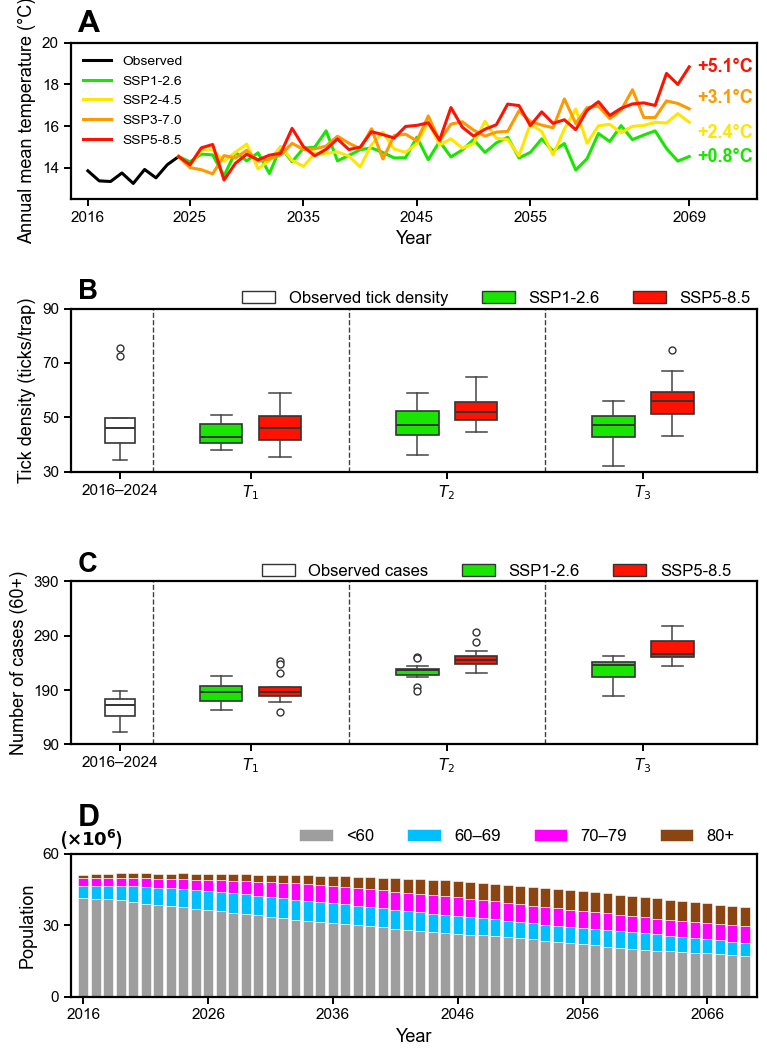

In [10]:
# ============================================================
# Figure 4.
# A: Annual mean temperature under SSP scenarios
# B: Tick density
# C: Number of cases (60+)
# D: Population by age group
# ============================================================


# ============================================================
# 0) 라이브러리 및 기본 설정
# ============================================================




# ============================================================
# 0-1) 저장 설정
# ============================================================

save_name = "Figure4.tiff"
save_path = os.path.join(figure_dir, save_name)


# read_excel_cached가 없을 경우 대비
try:
    read_excel_cached
except NameError:
    def read_excel_cached(path):
        return pd.read_excel(path)


# SAVE_FIG가 없을 경우 대비
try:
    SAVE_FIG
except NameError:
    SAVE_FIG = True


# ============================================================
# 1) 파일 경로 설정
# ============================================================

observed_file = base_path + "New_data11.xlsx"

temp_files = {
    "SSP1-2.6": base_path + "SSP126_weekly.xlsx",
    "SSP2-4.5": base_path + "SSP245_weekly.xlsx",
    "SSP3-7.0": base_path + "SSP370_weekly.xlsx",
    "SSP5-8.5": base_path + "SSP585_weekly.xlsx"
}

tick_files = {
    "SSP1-2.6": base_path + "SSP126_monthly_진드기_ver4.xlsx",
    "SSP5-8.5": base_path + "SSP585_monthly_진드기_ver4.xlsx"
}

case_files = {
    "SSP1-2.6": base_path + "forecasting_SSP126.xlsx",
    "SSP5-8.5": base_path + "forecasting_SSP585.xlsx"
}

fitted_case_path = base_path + "fitted_prediction_annual_case.xlsx"

population_file = base_path + "전국미래인구 데이터.xlsx"


# ============================================================
# 2) 시나리오 및 색상 설정
# ============================================================

scenario_order_all = [
    "SSP1-2.6",
    "SSP2-4.5",
    "SSP3-7.0",
    "SSP5-8.5"
]

scenario_order_box = [
    "SSP1-2.6",
    "SSP5-8.5"
]

temp_colors = {
    "SSP1-2.6": "#19e600",
    "SSP2-4.5": "#ffe600",
    "SSP3-7.0": "#ff9900",
    "SSP5-8.5": "#ff1200"
}

scenario_colors = {
    "SSP1-2.6": "#19e600",
    "SSP5-8.5": "#ff1200"
}

# Figure 4D 전용 연령군 색상
# A–C의 SSP 색상(녹색·노란색·주황색·빨간색)과 겹치지 않도록 구분
population_colors = {
    "<60": "#9E9E9E",
    "60–69": "#00BFFF",
    "70–79": "#FF00FF",
    "80+": "#8B4513"
}


# ============================================================
# 3) 기간 라벨 함수
# ============================================================

def assign_period(year):

    if 2025 <= year <= 2039:
        return r"$T_1$"

    elif 2040 <= year <= 2054:
        return r"$T_2$"

    elif 2055 <= year <= 2069:
        return r"$T_3$"

    else:
        return np.nan


period_order = [
    r"$T_1$",
    r"$T_2$",
    r"$T_3$"
]


# ============================================================
# 4) fitted_prediction_annual_case.xlsx에서 Cases 가져오는 함수
# ============================================================

def replace_cases_2025_2069(
    temp_df,
    scenario,
    cases_col="Cases"
):

    temp_df = temp_df.copy()

    temp_df.columns = (
        temp_df.columns
        .astype(str)
        .str.strip()
    )

    if (
        "year" in temp_df.columns
        and "Year" not in temp_df.columns
    ):
        temp_df = temp_df.rename(
            columns={"year": "Year"}
        )

    if "Year" not in temp_df.columns:
        raise ValueError(
            "forecasting SSP 파일에 'Year' 또는 "
            "'year' 컬럼이 필요합니다.\n"
            f"현재 컬럼: {list(temp_df.columns)}"
        )

    temp_df["Year"] = pd.to_numeric(
        temp_df["Year"],
        errors="coerce"
    ).astype("Int64")

    if cases_col in temp_df.columns:
        temp_df = temp_df.drop(
            columns=[cases_col]
        )

    replacement_df = read_excel_cached(
        fitted_case_path
    )

    replacement_df = replacement_df.copy()

    replacement_df.columns = (
        replacement_df.columns
        .astype(str)
        .str.strip()
    )

    if (
        "year" in replacement_df.columns
        and "Year" not in replacement_df.columns
    ):
        replacement_df = replacement_df.rename(
            columns={"year": "Year"}
        )

    if "Year" not in replacement_df.columns:
        raise ValueError(
            "fitted_prediction_annual_case.xlsx 파일에 "
            "'Year' 또는 'year' 컬럼이 필요합니다.\n"
            f"현재 컬럼: {list(replacement_df.columns)}"
        )

    replacement_df["Year"] = pd.to_numeric(
        replacement_df["Year"],
        errors="coerce"
    ).astype("Int64")

    scenario_col_candidates = {
        "SSP1-2.6": [
            "SSP126",
            "SSPSSP126",
            "SSP1-2.6"
        ],
        "SSP2-4.5": [
            "SSP245",
            "SSPSSP245",
            "SSP2-4.5"
        ],
        "SSP3-7.0": [
            "SSP370",
            "SSPSSP370",
            "SSP3-7.0"
        ],
        "SSP5-8.5": [
            "SSP585",
            "SSPSSP585",
            "SSP5-8.5"
        ]
    }

    fitted_col = None

    for col in scenario_col_candidates[scenario]:

        if col in replacement_df.columns:
            fitted_col = col
            break

    if fitted_col is None:
        raise ValueError(
            "fitted_prediction_annual_case.xlsx에서 "
            f"{scenario} 컬럼을 찾지 못했습니다.\n"
            f"현재 컬럼: {list(replacement_df.columns)}"
        )

    replacement_sub = replacement_df[
        ["Year", fitted_col]
    ].copy()

    replacement_sub = replacement_sub.rename(
        columns={fitted_col: cases_col}
    )

    replacement_sub[cases_col] = pd.to_numeric(
        replacement_sub[cases_col],
        errors="coerce"
    )

    replacement_sub = replacement_sub[
        (replacement_sub["Year"] >= 2025)
        & (replacement_sub["Year"] <= 2069)
    ].copy()

    temp_df = pd.merge(
        temp_df,
        replacement_sub,
        on="Year",
        how="left"
    )

    if temp_df.loc[
        (
            (temp_df["Year"] >= 2025)
            & (temp_df["Year"] <= 2069)
        ),
        cases_col
    ].isna().all():

        raise ValueError(
            f"{scenario}의 2025–2069 Cases 값이 "
            "모두 결측입니다.\n"
            "fitted_prediction_annual_case.xlsx의 "
            "Year와 시나리오 컬럼을 확인하세요."
        )

    return temp_df


# ============================================================
# 5) A: 평균기온 데이터 준비
# ============================================================

obs_temp_df = read_excel_cached(
    observed_file
)

obs_temp_df.columns = (
    obs_temp_df.columns
    .astype(str)
    .str.strip()
)

if (
    "year" in obs_temp_df.columns
    and "Year" not in obs_temp_df.columns
):
    obs_temp_df = obs_temp_df.rename(
        columns={"year": "Year"}
    )

if "tem" not in obs_temp_df.columns:
    raise ValueError(
        "New_data11.xlsx 파일에 평균기온 컬럼 "
        "'tem'이 없습니다.\n"
        f"현재 컬럼: {list(obs_temp_df.columns)}"
    )

obs_temp_df["Year"] = pd.to_numeric(
    obs_temp_df["Year"],
    errors="coerce"
).astype("Int64")

obs_temp_df["tem"] = pd.to_numeric(
    obs_temp_df["tem"],
    errors="coerce"
)

obs_temp_annual = (
    obs_temp_df[
        (obs_temp_df["Year"] >= 2016)
        & (obs_temp_df["Year"] <= 2024)
    ]
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        Annual_mean_temperature=(
            "tem",
            "mean"
        )
    )
)

observed_temp_baseline = (
    obs_temp_annual[
        "Annual_mean_temperature"
    ].mean()
)

print(
    "2016–2024 observed mean temperature: "
    f"{observed_temp_baseline:.2f} °C"
)


temp_annual_list = []

for scenario, path in temp_files.items():

    temp = read_excel_cached(path)

    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
    )

    if (
        "year" in temp.columns
        and "Year" not in temp.columns
    ):
        temp = temp.rename(
            columns={"year": "Year"}
        )

    if "tem" not in temp.columns:
        raise ValueError(
            f"{scenario} 파일에 평균기온 컬럼 "
            "'tem'이 없습니다.\n"
            f"현재 컬럼: {list(temp.columns)}"
        )

    temp["Year"] = pd.to_numeric(
        temp["Year"],
        errors="coerce"
    ).astype("Int64")

    temp["tem"] = pd.to_numeric(
        temp["tem"],
        errors="coerce"
    )

    temp = temp[
        (temp["Year"] >= 2025)
        & (temp["Year"] <= 2069)
    ].copy()

    annual_temp = (
        temp
        .groupby(
            "Year",
            as_index=False
        )
        .agg(
            Annual_mean_temperature=(
                "tem",
                "mean"
            )
        )
    )

    annual_temp["Scenario"] = scenario

    temp_annual_list.append(
        annual_temp
    )


temp_annual_df = pd.concat(
    temp_annual_list,
    ignore_index=True
)


# ============================================================
# 6) B, C: 관측 데이터 준비
# ============================================================

obs_df = read_excel_cached(
    observed_file
)

obs_df.columns = (
    obs_df.columns
    .astype(str)
    .str.strip()
)

if (
    "year" in obs_df.columns
    and "Year" not in obs_df.columns
):
    obs_df = obs_df.rename(
        columns={"year": "Year"}
    )

obs_df["Year"] = pd.to_numeric(
    obs_df["Year"],
    errors="coerce"
).astype("Int64")

obs_df = obs_df[
    (obs_df["Year"] >= 2016)
    & (obs_df["Year"] <= 2024)
].copy()


# ------------------------------------------------------------
# B: observed tick density
# ------------------------------------------------------------

if "Tick Density" not in obs_df.columns:
    raise ValueError(
        "New_data11.xlsx 파일에 "
        "'Tick Density' 컬럼이 없습니다.\n"
        f"현재 컬럼: {list(obs_df.columns)}"
    )

obs_df["Tick Density"] = pd.to_numeric(
    obs_df["Tick Density"],
    errors="coerce"
)

obs_tick_df = obs_df[
    obs_df["Tick Density"] > 0
].copy()

observed_tick_annual = (
    obs_tick_df
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        Tick_density=(
            "Tick Density",
            "mean"
        )
    )
)


# ------------------------------------------------------------
# C: observed cases 60+
# ------------------------------------------------------------

if "Cases_60" not in obs_df.columns:
    raise ValueError(
        "New_data11.xlsx 파일에 "
        "'Cases_60' 컬럼이 없습니다.\n"
        f"현재 컬럼: {list(obs_df.columns)}"
    )

obs_df["Cases_60"] = pd.to_numeric(
    obs_df["Cases_60"],
    errors="coerce"
)

observed_case_annual = (
    obs_df
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        Cases_60=(
            "Cases_60",
            "sum"
        )
    )
)


# ============================================================
# 7) B: 미래 tick density 준비
# ============================================================

tick_future_list = []

for scenario, path in tick_files.items():

    temp = read_excel_cached(path)

    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
    )

    if (
        "year" in temp.columns
        and "Year" not in temp.columns
    ):
        temp = temp.rename(
            columns={"year": "Year"}
        )

    if (
        "month" in temp.columns
        and "Month" not in temp.columns
    ):
        temp = temp.rename(
            columns={"month": "Month"}
        )

    if (
        "prediction" in temp.columns
        and "Prediction" not in temp.columns
    ):
        temp = temp.rename(
            columns={"prediction": "Prediction"}
        )

    required_tick_cols = [
        "Year",
        "Prediction"
    ]

    missing_tick_cols = [
        col
        for col in required_tick_cols
        if col not in temp.columns
    ]

    if len(missing_tick_cols) > 0:
        raise ValueError(
            f"{scenario} tick 파일에 필요한 "
            f"컬럼이 없습니다: {missing_tick_cols}\n"
            f"현재 컬럼: {list(temp.columns)}"
        )

    temp["Year"] = pd.to_numeric(
        temp["Year"],
        errors="coerce"
    ).astype("Int64")

    temp["Prediction"] = pd.to_numeric(
        temp["Prediction"],
        errors="coerce"
    )

    temp = temp[
        (temp["Year"] >= 2025)
        & (temp["Year"] <= 2069)
    ].copy()

    temp = temp[
        temp["Prediction"] > 0
    ].copy()

    annual_tick = (
        temp
        .groupby(
            "Year",
            as_index=False
        )
        .agg(
            Tick_density=(
                "Prediction",
                "mean"
            )
        )
    )

    annual_tick["Scenario"] = scenario

    annual_tick["Period"] = (
        annual_tick["Year"]
        .apply(assign_period)
    )

    tick_future_list.append(
        annual_tick
    )


tick_future_df = pd.concat(
    tick_future_list,
    ignore_index=True
)


# ============================================================
# 8) C: 미래 cases 준비
# ============================================================

case_future_list = []

for scenario, path in case_files.items():

    temp = pd.read_excel(path)

    temp = replace_cases_2025_2069(
        temp_df=temp,
        scenario=scenario,
        cases_col="Cases"
    )

    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
    )

    if (
        "year" in temp.columns
        and "Year" not in temp.columns
    ):
        temp = temp.rename(
            columns={"year": "Year"}
        )

    temp["Year"] = pd.to_numeric(
        temp["Year"],
        errors="coerce"
    ).astype("Int64")

    temp["Cases"] = pd.to_numeric(
        temp["Cases"],
        errors="coerce"
    )

    temp = temp[
        (temp["Year"] >= 2025)
        & (temp["Year"] <= 2069)
    ].copy()

    temp["Scenario"] = scenario

    temp["Period"] = (
        temp["Year"]
        .apply(assign_period)
    )

    case_future_list.append(
        temp[
            [
                "Year",
                "Cases",
                "Scenario",
                "Period"
            ]
        ]
    )


case_future_df = pd.concat(
    case_future_list,
    ignore_index=True
)


# ============================================================
# 9) D: 인구 데이터 준비
# ============================================================

pop_df = read_excel_cached(
    population_file
)

pop_df.columns = (
    pop_df.columns
    .astype(str)
    .str.strip()
)

if (
    "year" in pop_df.columns
    and "Year" not in pop_df.columns
):
    pop_df = pop_df.rename(
        columns={"year": "Year"}
    )

required_pop_cols = [
    "Year",
    "Population_0_60",
    "Population_60_70",
    "Population_70_80",
    "Population_80"
]

missing_pop_cols = [
    col
    for col in required_pop_cols
    if col not in pop_df.columns
]

if len(missing_pop_cols) > 0:
    raise ValueError(
        "인구 파일에 필요한 컬럼이 없습니다: "
        f"{missing_pop_cols}\n"
        f"현재 컬럼: {list(pop_df.columns)}"
    )

for col in required_pop_cols:

    pop_df[col] = pd.to_numeric(
        pop_df[col],
        errors="coerce"
    )

pop_df = pop_df[
    (pop_df["Year"] >= 2016)
    & (pop_df["Year"] <= 2069)
].copy()

pop_df["under_60_million"] = (
    pop_df["Population_0_60"]
    / 1_000_000
)

pop_df["age_60_69_million"] = (
    pop_df["Population_60_70"]
    / 1_000_000
)

pop_df["age_70_79_million"] = (
    pop_df["Population_70_80"]
    / 1_000_000
)

pop_df["age_80_plus_million"] = (
    pop_df["Population_80"]
    / 1_000_000
)


# ============================================================
# 10) 확인용 출력
# ============================================================

print("Observed annual temperature")
display(obs_temp_annual)

print("Observed annual tick density")
display(observed_tick_annual)

print("Observed annual cases 60+")
display(observed_case_annual)

print("Future annual tick density")
display(tick_future_df.head())

print("Future annual cases")
display(case_future_df.head())

print("Annual temperature")
display(temp_annual_df.head())

print("Population")
display(pop_df.head())


# ============================================================
# 11) 공통 스타일 함수
# ============================================================

def set_black_spines(
    ax,
    linewidth=1.6
):

    for spine in ax.spines.values():

        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)


def apply_common_style(ax):

    ax.grid(False)

    ax.tick_params(
        axis="both",
        labelsize=11,
        length=5,
        width=1.4,
        color="black"
    )

    for label in ax.get_xticklabels():
        label.set_fontfamily("Arial")

    for label in ax.get_yticklabels():
        label.set_fontfamily("Arial")

    set_black_spines(ax)


# ============================================================
# 12) B, C 박스플롯 함수
# ============================================================

def draw_combined_boxplot(
    ax,
    observed_values,
    future_df,
    value_col,
    ylabel,
    panel_label,
    observed_label,
    ylim=None,
    yticks=None
):

    group_edges = [
        0.0,
        1.0,
        4.0,
        7.0,
        10.0
    ]

    group_centers = [
        (
            group_edges[0]
            + group_edges[1]
        ) / 2,
        (
            group_edges[1]
            + group_edges[2]
        ) / 2,
        (
            group_edges[2]
            + group_edges[3]
        ) / 2,
        (
            group_edges[3]
            + group_edges[4]
        ) / 2
    ]

    obs_pos = [
        group_centers[0]
    ]

    offsets = [
        -0.45,
        0.45
    ]

    obs_width = 0.45
    future_width = 0.65

    # --------------------------------------------------------
    # Observed boxplot
    # --------------------------------------------------------

    bp_obs = ax.boxplot(
        [observed_values],
        positions=obs_pos,
        widths=obs_width,
        patch_artist=True,
        showfliers=True,
        whis=1.5
    )

    for patch in bp_obs["boxes"]:
        patch.set_facecolor("white")
        patch.set_edgecolor("#333333")
        patch.set_linewidth(1.2)

    for whisker in bp_obs["whiskers"]:
        whisker.set_color("#444444")
        whisker.set_linewidth(1.1)

    for cap in bp_obs["caps"]:
        cap.set_color("#444444")
        cap.set_linewidth(1.1)

    for median in bp_obs["medians"]:
        median.set_color("#333333")
        median.set_linewidth(1.4)

    for flier in bp_obs["fliers"]:
        flier.set(
            marker="o",
            markersize=5,
            markerfacecolor="white",
            markeredgecolor="#333333",
            linestyle="none"
        )

    # --------------------------------------------------------
    # 미래 시나리오별 boxplot
    # --------------------------------------------------------

    for i, scenario in enumerate(
        scenario_order_box
    ):

        data_list = []
        positions = []

        for j, period in enumerate(
            period_order
        ):

            vals = future_df.loc[
                (
                    future_df["Scenario"]
                    == scenario
                )
                & (
                    future_df["Period"]
                    == period
                ),
                value_col
            ].dropna().values

            data_list.append(vals)

            positions.append(
                group_centers[j + 1]
                + offsets[i]
            )

        bp = ax.boxplot(
            data_list,
            positions=positions,
            widths=future_width,
            patch_artist=True,
            showfliers=True,
            whis=1.5
        )

        for patch in bp["boxes"]:

            patch.set_facecolor(
                scenario_colors[scenario]
            )

            patch.set_edgecolor("#333333")
            patch.set_linewidth(1.2)

        for whisker in bp["whiskers"]:
            whisker.set_color("#444444")
            whisker.set_linewidth(1.1)

        for cap in bp["caps"]:
            cap.set_color("#444444")
            cap.set_linewidth(1.1)

        for median in bp["medians"]:
            median.set_color("#333333")
            median.set_linewidth(1.4)

        for flier in bp["fliers"]:
            flier.set(
                marker="o",
                markersize=5,
                markerfacecolor="white",
                markeredgecolor="#333333",
                linestyle="none"
            )

    # --------------------------------------------------------
    # 구분선
    # --------------------------------------------------------

    for xline in group_edges[1:-1]:

        ax.axvline(
            xline,
            color="black",
            linestyle="--",
            linewidth=1.0,
            alpha=0.75
        )

    ax.set_xlim(
        group_edges[0] - 0.25,
        group_edges[-1] + 0.25
    )

    ax.set_xticks(
        group_centers
    )

    ax.set_xticklabels(
        [
            "2016–2024",
            r"$T_1$",
            r"$T_2$",
            r"$T_3$"
        ],
        fontsize=14,
        fontfamily="Arial"
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontfamily="Arial"
    )

    if ylim is not None:
        ax.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    ax.text(
        0.01,
        1.02,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        ha="left",
        va="bottom",
        fontfamily="Arial"
    )

    apply_common_style(ax)

    legend_handles = [
        Patch(
            facecolor="white",
            edgecolor="#333333",
            label=observed_label
        )
    ] + [
        Patch(
            facecolor=scenario_colors[s],
            edgecolor="#333333",
            label=s
        )
        for s in scenario_order_box
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.62, 1.20),
        ncol=3,
        frameon=False,
        fontsize=12
    )


# ============================================================
# 13) Figure layout
# ============================================================

fig = plt.figure(
    figsize=(8.8, 10.6)
)

gs = GridSpec(
    4,
    1,
    height_ratios=[
        1.15,
        1.2,
        1.2,
        1.05
    ],
    hspace=0.70
)

axA = fig.add_subplot(
    gs[0, 0]
)

axB = fig.add_subplot(
    gs[1, 0]
)

axC = fig.add_subplot(
    gs[2, 0]
)

axD = fig.add_subplot(
    gs[3, 0]
)


# ============================================================
# 14) A: Annual mean temperature
#    - 2065 x축 눈금 제거
#    - +2.4°C와 +3.1°C 간격 확대
# ============================================================

axA.plot(
    obs_temp_annual["Year"],
    obs_temp_annual[
        "Annual_mean_temperature"
    ],
    color="black",
    linewidth=2.2,
    label="Observed"
)

obs_last_year = int(
    obs_temp_annual["Year"].max()
)

obs_last_temp = obs_temp_annual.loc[
    (
        obs_temp_annual["Year"]
        == obs_last_year
    ),
    "Annual_mean_temperature"
].iloc[0]


# ------------------------------------------------------------
# 시나리오별 증가량 글씨 위치
#
# SSP2-4.5: 위쪽 이동
# SSP3-7.0: 아래쪽 이동
# ------------------------------------------------------------

temperature_label_offsets = {
    "SSP1-2.6": (6, 0),
    "SSP2-4.5": (6, -8),
    "SSP3-7.0": (6, 8),
    "SSP5-8.5": (6, 0)
}


for scenario in scenario_order_all:

    temp = temp_annual_df[
        temp_annual_df["Scenario"]
        == scenario
    ].copy()

    temp = temp.sort_values(
        "Year"
    )

    connect_df = pd.DataFrame({
        "Year": [
            obs_last_year
        ],
        "Annual_mean_temperature": [
            obs_last_temp
        ]
    })

    plot_temp = pd.concat(
        [
            connect_df,
            temp[
                [
                    "Year",
                    "Annual_mean_temperature"
                ]
            ]
        ],
        ignore_index=True
    )

    axA.plot(
        plot_temp["Year"],
        plot_temp[
            "Annual_mean_temperature"
        ],
        color=temp_colors[scenario],
        linewidth=2.2,
        label=scenario
    )

    temp_2069 = temp.loc[
        temp["Year"] == 2069,
        "Annual_mean_temperature"
    ]

    if len(temp_2069) > 0:

        temp_2069_value = (
            temp_2069.iloc[0]
        )

        diff_from_obs = (
            temp_2069_value
            - observed_temp_baseline
        )

        x_offset, y_offset = (
            temperature_label_offsets[
                scenario
            ]
        )

        axA.annotate(
            f"+{diff_from_obs:.1f}°C",
            xy=(
                2069,
                temp_2069_value
            ),
            xytext=(
                x_offset,
                y_offset
            ),
            textcoords="offset points",
            color=temp_colors[scenario],
            fontsize=13,
            fontfamily="Arial",
            fontweight="bold",
            va="center",
            ha="left",
            annotation_clip=False
        )


axA.set_ylabel(
    "Annual mean temperature (°C)",
    fontsize=13,
    fontfamily="Arial"
)

axA.set_xlabel(
    "Year",
    fontsize=13,
    fontfamily="Arial"
)

axA.set_xlim(
    2014.5,
    2075.0
)

# 2065 제거
axA.set_xticks(
    [
        2016,
        2025,
        2035,
        2045,
        2055,
        2069
    ]
)

temp_min = min(
    obs_temp_annual[
        "Annual_mean_temperature"
    ].min(),
    temp_annual_df[
        "Annual_mean_temperature"
    ].min(),
    observed_temp_baseline
)

temp_max = max(
    obs_temp_annual[
        "Annual_mean_temperature"
    ].max(),
    temp_annual_df[
        "Annual_mean_temperature"
    ].max(),
    observed_temp_baseline
)

axA.set_ylim(
    np.floor(temp_min) - 0.5,
    np.ceil(temp_max) + 1.0
)

axA.text(
    0.01,
    1.03,
    "A",
    transform=axA.transAxes,
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="bottom",
    fontfamily="Arial"
)

axA.legend(
    loc="upper left",
    frameon=False,
    fontsize=10,
    ncol=1
)

apply_common_style(axA)


# ============================================================
# 15) B: Tick density
# ============================================================

draw_combined_boxplot(
    ax=axB,
    observed_values=(
        observed_tick_annual[
            "Tick_density"
        ].values
    ),
    future_df=tick_future_df,
    value_col="Tick_density",
    ylabel="Tick density (ticks/trap)",
    panel_label="B",
    observed_label="Observed tick density",
    ylim=(30, 90),
    yticks=[
        30,
        50,
        70,
        90
    ]
)


# ============================================================
# 16) C: Cases 60+
# ============================================================

draw_combined_boxplot(
    ax=axC,
    observed_values=(
        observed_case_annual[
            "Cases_60"
        ].values
    ),
    future_df=case_future_df,
    value_col="Cases",
    ylabel="Number of cases (60+)",
    panel_label="C",
    observed_label="Observed cases",
    ylim=(90, 390),
    yticks=[
        90,
        190,
        290,
        390
    ]
)


# ============================================================
# 17) D: Population stacked bar
#    - y축 제목은 Population
#    - ×10⁶은 y축 왼쪽 위에 굵게 표시
# ============================================================

years = (
    pop_df["Year"]
    .astype(int)
    .values
)

under_60 = (
    pop_df[
        "under_60_million"
    ].values
)

age_60_69 = (
    pop_df[
        "age_60_69_million"
    ].values
)

age_70_79 = (
    pop_df[
        "age_70_79_million"
    ].values
)

age_80_plus = (
    pop_df[
        "age_80_plus_million"
    ].values
)


axD.bar(
    years,
    under_60,
    color=population_colors["<60"],
    edgecolor="white",
    linewidth=0.4,
    width=0.8,
    label="<60"
)

axD.bar(
    years,
    age_60_69,
    bottom=under_60,
    color=population_colors["60–69"],
    edgecolor="white",
    linewidth=0.4,
    width=0.8,
    label="60–69"
)

axD.bar(
    years,
    age_70_79,
    bottom=(
        under_60
        + age_60_69
    ),
    color=population_colors["70–79"],
    edgecolor="white",
    linewidth=0.4,
    width=0.8,
    label="70–79"
)

axD.bar(
    years,
    age_80_plus,
    bottom=(
        under_60
        + age_60_69
        + age_70_79
    ),
    color=population_colors["80+"],
    edgecolor="white",
    linewidth=0.4,
    width=0.8,
    label="80+"
)


axD.set_ylabel(
    "Population",
    fontsize=13,
    fontfamily="Arial"
)


# y축 눈금 위쪽에 ×10⁶ 표시
axD.text(
    0.03,
    1.015,
    r"($\mathbf{\times 10^{6}}$)",
    transform=axD.transAxes,
    fontsize=13,
    fontfamily="Arial",
    fontweight="bold",
    ha="center",
    va="bottom",
    clip_on=False
)


axD.set_xlabel(
    "Year",
    fontsize=13,
    fontfamily="Arial"
)

axD.set_xlim(
    2015,
    2070
)

axD.set_xticks(
    [
        2016,
        2026,
        2036,
        2046,
        2056,
        2066
    ]
)

axD.set_ylim(
    0,
    60
)

axD.set_yticks(
    [
        0,
        30,
        60
    ]
)

axD.text(
    0.01,
    1.15,
    "D",
    transform=axD.transAxes,
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="bottom",
    fontfamily="Arial"
)

axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.65, 1.22),
    frameon=False,
    fontsize=12,
    ncol=4,
    borderaxespad=0.0
)

apply_common_style(axD)


# ============================================================
# 18) 저장 및 출력
# ============================================================

plt.subplots_adjust(
    left=0.12,
    right=0.90,
    top=0.97,
    bottom=0.07,
    hspace=0.70
)

if SAVE_FIG:

    os.makedirs(
        figure_dir,
        exist_ok=True
    )

    plt.savefig(
        save_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight",
        pad_inches=0.30
    )

    print(
        f"저장 완료: {save_path}"
    )

plt.show()

## Figure 5. Age-specific deaths and population structure

In [11]:
# ============================================================
# 연령대별 확진자 및 사망자 계산 + 15년 평균 요약 + 박스플롯
# 60~69, 70~79, 80+
# 기간: 2025~2069
#
# Figure:
# A: 60–69 사망자
# B: 70–79 사망자
# C: 80+ 사망자
# D 삭제
#
# x축 구간 폭:
# 2016–2024 : 2025–2039 : 2040–2054 : 2055–2069 = 1:3:3:3
#
# 중요:
# - Cases는 forecasting_SSP*.xlsx의 Cases가 아니라
#   fitted_prediction_annual_case.xlsx의 fitted 값을 사용
# - CI는 fitted 파일의 15년 구간 연도별 15개 값에서 직접 계산
# ============================================================


# ============================================================
# 1) 저장 설정
# ============================================================
save_name = "Figure5.tiff"
save_path = os.path.join(figure_dir, save_name)


# ============================================================
# 2) 시나리오별 예측 파일
#    기존 변수명 호환용. CI 계산에는 사용하지 않음
# ============================================================
scenario_files = {
    "SSP1-2.6": base_path + "forecasting_SSP126.xlsx",
    "SSP2-4.5": base_path + "forecasting_SSP245.xlsx",
    "SSP3-7.0": base_path + "forecasting_SSP370.xlsx",
    "SSP5-8.5": base_path + "forecasting_SSP585.xlsx"
}


# ============================================================
# 3) fitted, 인구 및 관측 데이터 파일
# ============================================================
fitted_case_path = os.path.join(base_path, "fitted_prediction_annual_case.xlsx")
population_path = os.path.join(base_path, "전국미래인구 데이터.xlsx")
observed_path = os.path.join(base_path, "New_data11.xlsx")


# ============================================================
# 4) 연령대별 치사율
# ============================================================
death_rates = {
    "60_70": 0.1134,
    "70_80": 0.2311,
    "80": 0.2848
}


# ============================================================
# 5) 색상 설정
# ============================================================
obs_color = "white"
ssp126_col = "#00E600"
ssp585_col = "#FF1A1A"


# ============================================================
# 6) 공통 Year 컬럼 정리 함수
# ============================================================
def clean_year_column(df):
    temp = df.copy()
    temp.columns = temp.columns.astype(str).str.strip()

    if "year" in temp.columns and "Year" not in temp.columns:
        temp = temp.rename(columns={"year": "Year"})

    if "Year" not in temp.columns:
        raise KeyError(
            f"Year 컬럼을 찾지 못했습니다.\n"
            f"현재 컬럼: {list(temp.columns)}"
        )

    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce").astype("Int64")

    return temp


# ============================================================
# 7) fitted_prediction_annual_case.xlsx 불러오기
#    컬럼 예:
#    Year, Week, SSP126, SSP245, SSP370, SSP585
# ============================================================
def load_fitted_case_long_for_death(fitted_case_path):
    fitted_df = read_excel_cached(fitted_case_path)
    fitted_df = clean_year_column(fitted_df)

    scenario_col_candidates = {
        "SSP1-2.6": ["SSP126", "SSPSSP126", "SSP1-2.6"],
        "SSP2-4.5": ["SSP245", "SSPSSP245", "SSP2-4.5"],
        "SSP3-7.0": ["SSP370", "SSPSSP370", "SSP3-7.0"],
        "SSP5-8.5": ["SSP585", "SSPSSP585", "SSP5-8.5"]
    }

    fitted_list = []

    for scenario, candidates in scenario_col_candidates.items():

        fitted_col = None

        for col in candidates:
            if col in fitted_df.columns:
                fitted_col = col
                break

        if fitted_col is None:
            raise KeyError(
                f"{scenario}에 해당하는 fitted 컬럼을 찾지 못했습니다.\n"
                f"찾은 후보: {candidates}\n"
                f"현재 컬럼: {list(fitted_df.columns)}"
            )

        temp = fitted_df[["Year", fitted_col]].copy()
        temp = temp.rename(columns={fitted_col: "Cases"})
        temp["Cases"] = pd.to_numeric(temp["Cases"], errors="coerce")
        temp["Scenario"] = scenario

        fitted_list.append(temp)

    fitted_long = pd.concat(fitted_list, ignore_index=True)

    return fitted_long


In [12]:
# ============================================================
# 8) 연령대별 확진자 및 사망자 계산 함수
#    Cases는 fitted 파일에서 가져온 값만 사용
#    CI용 p025, p50, p975는 더 이상 forecasting 파일에서 읽지 않음
# ============================================================
def calculate_age_specific_deaths(
    scenario_files=None,
    fitted_case_path=None,
    population_path=None,
    start_year=2025,
    end_year=2069,
    case_col="Cases",
    lower_col=None,
    median_col=None,
    upper_col=None
):
    """
    fitted_prediction_annual_case.xlsx의 fitted Cases를 이용해
    60세 이상 전체 확진자를 시나리오별로 가져온다.

    이후 60~69세, 70~79세, 80세 이상 인구 비율로 나눈 뒤,
    각 연령대별 치사율을 곱해 연령대별 사망자를 계산한다.

    중요:
    - CI 계산을 위해 forecasting_SSP*.xlsx의 p025/p975를 사용하지 않는다.
    - 15년 단위 CI는 summarize_age_deaths_15year_with_ci()에서
      fitted 기반 연도별 15개 사망자 값의 분위수로 계산한다.
    - 기존 실행부와 호환되도록 scenario_files, lower_col 등 인자는 남겨두지만 사용하지 않는다.
    """

    if fitted_case_path is None:
        raise ValueError("fitted_case_path를 지정해야 합니다.")

    if population_path is None:
        raise ValueError("population_path를 지정해야 합니다.")

    # --------------------------------------------------------
    # fitted Cases 데이터 불러오기
    # --------------------------------------------------------
    fitted_long = load_fitted_case_long_for_death(fitted_case_path)

    fitted_long = fitted_long[
        (fitted_long["Year"] >= start_year) &
        (fitted_long["Year"] <= end_year)
    ].copy()

    # --------------------------------------------------------
    # 인구 비율 데이터 불러오기
    # --------------------------------------------------------
    pop_df = read_excel_cached(population_path)
    pop_df = clean_year_column(pop_df)

    pop_df = pop_df[
        (pop_df["Year"] >= start_year) &
        (pop_df["Year"] <= end_year)
    ].copy()

    pop_use_cols = [
        "Year",
        "Population_60",
        "Population_60_70",
        "Population_70_80",
        "Population_80",
        "60~70세 비율(%)",
        "70~80세 비율(%)",
        "80세 이상 비율(%)"
    ]

    missing_pop_cols = [
        col for col in pop_use_cols
        if col not in pop_df.columns
    ]

    if missing_pop_cols:
        raise KeyError(
            f"인구 데이터에 필요한 컬럼이 없습니다: {missing_pop_cols}\n"
            f"현재 컬럼: {list(pop_df.columns)}"
        )

    pop_df = pop_df[pop_use_cols].copy()

    pop_df = pop_df.rename(columns={
        "60~70세 비율(%)": "ratio_60_70",
        "70~80세 비율(%)": "ratio_70_80",
        "80세 이상 비율(%)": "ratio_80"
    })

    # 혹시 비율 컬럼이 35, 40 같은 퍼센트 단위이면 100으로 나눔
    ratio_cols = ["ratio_60_70", "ratio_70_80", "ratio_80"]

    for col in ratio_cols:
        pop_df[col] = pd.to_numeric(pop_df[col], errors="coerce")

        if pop_df[col].max() > 1:
            pop_df[col] = pop_df[col] / 100

    # --------------------------------------------------------
    # fitted Cases + 인구 비율 결합
    # --------------------------------------------------------
    merged = pd.merge(
        fitted_long,
        pop_df,
        on="Year",
        how="left"
    )

    if merged[case_col].isna().all():
        raise ValueError(
            "fitted Cases 값이 모두 결측입니다.\n"
            "fitted_prediction_annual_case.xlsx의 Year와 시나리오 컬럼을 확인하세요."
        )

    # --------------------------------------------------------
    # 연령대별 확진자 계산
    # --------------------------------------------------------
    merged["Cases_60_70"] = merged[case_col] * merged["ratio_60_70"]
    merged["Cases_70_80"] = merged[case_col] * merged["ratio_70_80"]
    merged["Cases_80"]    = merged[case_col] * merged["ratio_80"]

    # --------------------------------------------------------
    # 연령대별 사망자 계산
    # fitted Cases 기준
    # --------------------------------------------------------
    merged["Deaths_60_70"] = merged["Cases_60_70"] * death_rates["60_70"]
    merged["Deaths_70_80"] = merged["Cases_70_80"] * death_rates["70_80"]
    merged["Deaths_80"]    = merged["Cases_80"]    * death_rates["80"]

    merged["Deaths_total"] = (
        merged["Deaths_60_70"] +
        merged["Deaths_70_80"] +
        merged["Deaths_80"]
    )

    return merged


# ============================================================
# 9) 관측값 2016–2024 연령대별 사망자 계산 함수
# ============================================================
def calculate_observed_age_deaths(
    observed_path,
    start_year=2016,
    end_year=2024
):
    obs = read_excel_cached(observed_path)
    obs = clean_year_column(obs)

    obs = obs[
        (obs["Year"] >= start_year) &
        (obs["Year"] <= end_year)
    ].copy()

    required_cols = ["Cases_60_70", "Cases_70_80", "Cases_80"]

    missing_cols = [
        col for col in required_cols
        if col not in obs.columns
    ]

    if missing_cols:
        raise ValueError(f"관측 데이터에 다음 컬럼이 없습니다: {missing_cols}")

    annual_obs = (
        obs.groupby("Year", as_index=False)[required_cols]
        .sum()
    )

    annual_obs["Deaths_60_70"] = (
        annual_obs["Cases_60_70"] *
        death_rates["60_70"]
    )

    annual_obs["Deaths_70_80"] = (
        annual_obs["Cases_70_80"] *
        death_rates["70_80"]
    )

    annual_obs["Deaths_80"] = (
        annual_obs["Cases_80"] *
        death_rates["80"]
    )

    annual_obs["Deaths_total"] = (
        annual_obs["Deaths_60_70"] +
        annual_obs["Deaths_70_80"] +
        annual_obs["Deaths_80"]
    )

    return annual_obs


# ============================================================
# 10) 15년 단위 평균 사망자 및 95% CI 요약 함수
# ============================================================
def summarize_age_deaths_15year_with_ci(age_death_df):
    """
    연도별·시나리오별 연령대 사망자 결과를 이용해
    15년 단위 평균 사망자와 95% CI 하한/상한을 계산한다.

    중요:
    - 다른 forecasting_SSP*.xlsx의 p025/p975를 사용하지 않는다.
    - 각 15년 구간의 fitted 기반 연도별 사망자 15개 값만 사용한다.
    - Mean: 15개 값의 평균
    - 95% CI: 15개 값의 2.5%, 97.5% 분위수
    """

    periods = [
        (2025, 2039, "2025–2039"),
        (2040, 2054, "2040–2054"),
        (2055, 2069, "2055–2069")
    ]

    rows = []

    for scenario in age_death_df["Scenario"].unique():
        temp_s = age_death_df[
            age_death_df["Scenario"] == scenario
        ].copy()

        for start_year, end_year, period_label in periods:
            temp = temp_s[
                (temp_s["Year"] >= start_year) &
                (temp_s["Year"] <= end_year)
            ].copy()

            d6070 = temp["Deaths_60_70"].dropna()
            d7080 = temp["Deaths_70_80"].dropna()
            d80   = temp["Deaths_80"].dropna()
            dtotal = temp["Deaths_total"].dropna()

            rows.append({
                "Scenario": scenario,
                "Period": period_label,

                "Deaths 60–69 Mean": d6070.mean(),
                "Deaths 60–69 95% CI Lower": d6070.quantile(0.025),
                "Deaths 60–69 95% CI Upper": d6070.quantile(0.975),

                "Deaths 70–79 Mean": d7080.mean(),
                "Deaths 70–79 95% CI Lower": d7080.quantile(0.025),
                "Deaths 70–79 95% CI Upper": d7080.quantile(0.975),

                "Deaths 80+ Mean": d80.mean(),
                "Deaths 80+ 95% CI Lower": d80.quantile(0.025),
                "Deaths 80+ 95% CI Upper": d80.quantile(0.975),

                "Total Deaths Mean": dtotal.mean(),
                "Total Deaths 95% CI Lower": dtotal.quantile(0.025),
                "Total Deaths 95% CI Upper": dtotal.quantile(0.975),

                "N_years": temp["Year"].nunique()
            })

    summary_df = pd.DataFrame(rows)

    return summary_df


# ============================================================
# 11) 박스플롯 데이터 추출 함수
# ============================================================
periods = [
    (2025, 2039, "T1"),
    (2040, 2054, "T2"),
    (2055, 2069, "T3")
]


def get_box_data_observed(obs_df, death_col):
    return obs_df[death_col].dropna().values


def get_box_data_scenario(df, scenario, death_col, start_year, end_year):
    sub = df[
        (df["Scenario"] == scenario) &
        (df["Year"] >= start_year) &
        (df["Year"] <= end_year)
    ].copy()

    return sub[death_col].dropna().values


# ============================================================
# 12) 박스플롯 스타일 함수
# ============================================================
def style_box(ax, bp, facecolor):
    for box in bp["boxes"]:
        box.set(
            facecolor=facecolor,
            edgecolor="black",
            linewidth=1.2
        )

    for whisker in bp["whiskers"]:
        whisker.set(
            color="dimgray",
            linewidth=1.0
        )

    for cap in bp["caps"]:
        cap.set(
            color="dimgray",
            linewidth=1.0
        )

    for median in bp["medians"]:
        median.set(
            color="black",
            linewidth=1.2
        )

    for flier in bp["fliers"]:
        flier.set(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
            alpha=0.8
        )


def set_axis_style(ax):
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    ax.tick_params(
        axis="both",
        labelsize=12,
        width=1.1,
        length=4
    )


,Year,Cases,Scenario,Population_60,Population_60_70,Population_70_80,Population_80,ratio_60_70,ratio_70_80,ratio_80,Cases_60_70,Cases_70_80,Cases_80,Deaths_60_70,Deaths_70_80,Deaths_80,Deaths_total
0,2025,153.11,SSP1-2.6,14669373,7844071,4347619,2477683,0.5347,0.2964,0.1689,81.87,45.38,25.86,9.28,10.49,7.37,27.14
1,2026,161.61,SSP1-2.6,15167654,7980101,4665354,2522199,0.5261,0.3076,0.1663,85.03,49.71,26.87,9.64,11.49,7.65,28.78
2,2027,186.09,SSP1-2.6,15642897,8068291,4907263,2667343,0.5158,0.3137,0.1705,95.98,58.38,31.73,10.88,13.49,9.04,33.41
3,2028,154.34,SSP1-2.6,16130955,8139161,5183887,2807907,0.5046,0.3214,0.1741,77.87,49.60,26.87,8.83,11.46,7.65,27.94
4,2029,167.23,SSP1-2.6,16697331,8263910,5496486,2936935,0.4949,0.3292,0.1759,82.77,55.05,29.42,9.39,12.72,8.38,30.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2065,249.61,SSP5-8.5,21273619,6232143,6572600,8468876,0.2930,0.3090,0.3981,73.12,77.12,99.37,8.29,17.82,28.30,54.42
176,2066,253.98,SSP5-8.5,21031620,5989713,6646993,8394914,0.2848,0.3160,0.3992,72.33,80.27,101.38,8.20,18.55,28.87,55.63
177,2067,308.30,SSP5-8.5,20812991,5785564,6716468,8310959,0.2780,0.3227,0.3993,85.70,99.49,123.11,9.72,22.99,35.06,67.77
178,2068,275.71,SSP5-8.5,20627476,5622822,6780702,8223952,0.2726,0.3287,0.3987,75.16,90.63,109.92,8.52,20.94,31.31,60.77


,Scenario,Period,Deaths 60–69 Mean,Deaths 60–69 95% CI Lower,Deaths 60–69 95% CI Upper,Deaths 70–79 Mean,Deaths 70–79 95% CI Lower,Deaths 70–79 95% CI Upper,Deaths 80+ Mean,Deaths 80+ 95% CI Lower,Deaths 80+ 95% CI Upper,Total Deaths Mean,Total Deaths 95% CI Lower,Total Deaths 95% CI Upper,N_years
0,SSP1-2.6,2025–2039,9.53,8.05,10.87,14.80,10.83,18.09,10.06,7.47,13.18,34.40,27.42,41.10,15
1,SSP1-2.6,2040–2054,8.45,7.04,10.32,17.84,14.89,20.32,20.17,15.77,25.22,46.47,40.05,52.56,15
2,SSP1-2.6,2055–2069,7.79,5.69,8.66,16.33,13.99,17.82,25.10,20.86,28.37,49.23,40.95,54.49,15
3,SSP2-4.5,2025–2039,9.95,8.34,11.10,15.39,11.85,19.56,10.49,8.03,14.82,35.82,29.58,44.54,15
4,SSP2-4.5,2040–2054,8.61,7.03,10.01,18.20,15.21,21.03,20.62,14.92,25.34,47.42,39.63,55.12,15
5,SSP2-4.5,2055–2069,8.20,7.05,9.40,17.28,15.38,19.81,26.52,23.56,29.84,52.01,46.75,57.85,15
6,SSP3-7.0,2025–2039,9.88,8.85,10.75,15.46,10.74,19.44,10.56,7.41,15.42,35.90,27.35,45.04,15
7,SSP3-7.0,2040–2054,9.04,7.77,10.45,19.10,16.90,21.07,21.68,16.46,27.93,49.82,43.50,57.06,15
8,SSP3-7.0,2055–2069,8.85,7.96,10.18,18.65,16.86,20.79,28.64,25.56,31.13,56.14,51.34,61.46,15
9,SSP5-8.5,2025–2039,9.94,8.64,11.74,15.47,10.91,20.55,10.54,7.52,14.78,35.95,27.75,46.51,15


C:\Users\Main\AppData\Local\Temp\ipykernel_13180\2239655141.py:372: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


저장 완료: C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Figure5.tiff


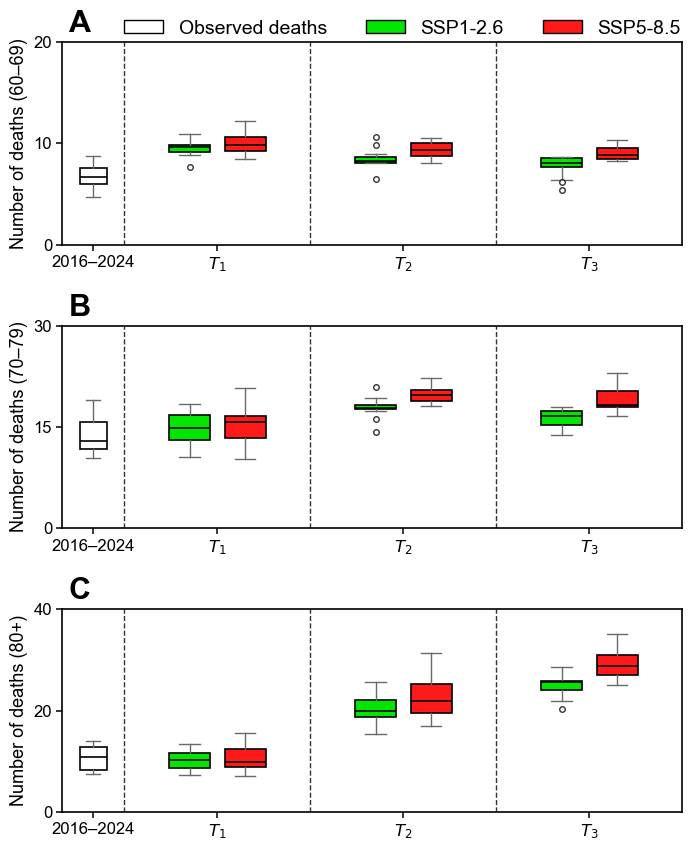

In [13]:
# ============================================================
# 13) 연령대별 박스플롯 그리는 함수
#     구간 폭: 1:3:3:3
# ============================================================
def plot_age_death_boxplot(
    ax,
    observed_death_df,
    age_death_plot,
    death_col,
    ylabel,
    panel_label,
    ylim=None,
    yticks=None
):
    group_centers = [0.5, 2.5, 5.5, 8.5]

    tick_labels = [
        "2016–2024",
         r"$T_1$", 
         r"$T_2$", 
         r"$T_3$"
    ]

    obs_pos = [0.5]

    ssp126_positions = [
        2.5 - 0.45,
        5.5 - 0.45,
        8.5 - 0.45
    ]

    ssp585_positions = [
        2.5 + 0.45,
        5.5 + 0.45,
        8.5 + 0.45
    ]

    obs_box_width = 0.45
    scenario_box_width = 0.65

    # --------------------------------------------------------
    # 관측값
    # --------------------------------------------------------
    obs_data = get_box_data_observed(
        observed_death_df,
        death_col
    )

    bp = ax.boxplot(
        [obs_data],
        positions=obs_pos,
        widths=obs_box_width,
        patch_artist=True
    )

    style_box(ax, bp, obs_color)

    # --------------------------------------------------------
    # SSP1-2.6
    # --------------------------------------------------------
    ssp126_data = [
        get_box_data_scenario(
            age_death_plot,
            "SSP1-2.6",
            death_col,
            start_year,
            end_year
        )
        for start_year, end_year, _ in periods
    ]

    bp = ax.boxplot(
        ssp126_data,
        positions=ssp126_positions,
        widths=scenario_box_width,
        patch_artist=True
    )

    style_box(ax, bp, ssp126_col)

    # --------------------------------------------------------
    # SSP5-8.5
    # --------------------------------------------------------
    ssp585_data = [
        get_box_data_scenario(
            age_death_plot,
            "SSP5-8.5",
            death_col,
            start_year,
            end_year
        )
        for start_year, end_year, _ in periods
    ]

    bp = ax.boxplot(
        ssp585_data,
        positions=ssp585_positions,
        widths=scenario_box_width,
        patch_artist=True
    )

    style_box(ax, bp, ssp585_col)

    # --------------------------------------------------------
    # 구간 구분선
    # --------------------------------------------------------
    for x in [1, 4, 7]:
        ax.axvline(
            x,
            color="black",
            linestyle="--",
            linewidth=1.0,
            alpha=0.8
        )

    ax.set_xlim(0, 10)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        tick_labels,
        fontsize=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13
    )

    ax.text(
        0.01,
        1.02,
        panel_label,
        transform=ax.transAxes,
        fontsize=22,
        fontweight="bold",
        va="bottom"
    )

    if ylim is not None:
        ax.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    set_axis_style(ax)


# ============================================================
# 14) 연령대별 사망자 계산 실행
#     Cases는 fitted_prediction_annual_case.xlsx 기준
# ============================================================
# ------------------------------------------------------------
# 경로 재확인: 이 셀만 따로 실행해도 population_path 누락 오류가 나지 않도록 함
# ------------------------------------------------------------
fitted_case_path = os.path.join(base_path, "fitted_prediction_annual_case.xlsx")
population_path = os.path.join(base_path, "전국미래인구 데이터.xlsx")
observed_path = os.path.join(base_path, "New_data11.xlsx")

age_death_df = calculate_age_specific_deaths(
    scenario_files=scenario_files,
    fitted_case_path=fitted_case_path,
    population_path=population_path,
    start_year=2025,
    end_year=2069,
    case_col="Cases",
    lower_col="p025",
    median_col="p50",
    upper_col="p975"
)


# ============================================================
# 15) 계산 결과 출력용 반올림
# ============================================================
age_death_print = age_death_df.copy()

round_cols = [
    "Cases",
    "Cases_60_70",
    "Cases_70_80",
    "Cases_80",
    "Deaths_60_70",
    "Deaths_70_80",
    "Deaths_80",
    "Deaths_total",
    "Deaths_60_70_p025",
    "Deaths_70_80_p025",
    "Deaths_80_p025",
    "Deaths_total_p025",
    "Deaths_60_70_p50",
    "Deaths_70_80_p50",
    "Deaths_80_p50",
    "Deaths_total_p50",
    "Deaths_60_70_p975",
    "Deaths_70_80_p975",
    "Deaths_80_p975",
    "Deaths_total_p975"
]

for col in round_cols:
    if col in age_death_print.columns:
        age_death_print[col] = age_death_print[col].round(2)

ratio_cols = [
    "ratio_60_70",
    "ratio_70_80",
    "ratio_80"
]

for col in ratio_cols:
    if col in age_death_print.columns:
        age_death_print[col] = age_death_print[col].round(4)

display(age_death_print)


# ============================================================
# 16) 15년 단위 평균 사망자 및 95% CI 요약 실행
#     Mean은 fitted 기반 사망자 평균
# ============================================================
age_death_15year_ci = summarize_age_deaths_15year_with_ci(
    age_death_df
)

age_death_15year_ci_print = age_death_15year_ci.copy()

round_cols_15year = [
    "Deaths 60–69 Mean",
    "Deaths 60–69 95% CI Lower",
    "Deaths 60–69 95% CI Upper",

    "Deaths 70–79 Mean",
    "Deaths 70–79 95% CI Lower",
    "Deaths 70–79 95% CI Upper",

    "Deaths 80+ Mean",
    "Deaths 80+ 95% CI Lower",
    "Deaths 80+ 95% CI Upper",

    "Total Deaths Mean",
    "Total Deaths 95% CI Lower",
    "Total Deaths 95% CI Upper"
]

for col in round_cols_15year:
    if col in age_death_15year_ci_print.columns:
        age_death_15year_ci_print[col] = age_death_15year_ci_print[col].round(2)

display(age_death_15year_ci_print)


# ============================================================
# 17) 관측값 2016–2024 연령대별 사망자 계산
# ============================================================
observed_death_df = calculate_observed_age_deaths(
    observed_path=observed_path,
    start_year=2016,
    end_year=2024
)


# ============================================================
# 18) 그림에 표시할 시나리오만 선택
# ============================================================
plot_scenarios = [
    "SSP1-2.6",
    "SSP5-8.5"
]

age_death_plot = age_death_df[
    age_death_df["Scenario"].isin(plot_scenarios)
].copy()


# ============================================================
# 19) 그림 생성
#     D 삭제: 3행만 생성
# ============================================================
fig = plt.figure(figsize=(8, 10))

gs = fig.add_gridspec(
    3,
    1,
    height_ratios=[1, 1, 1],
    hspace=0.40
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[1, 0])
axC = fig.add_subplot(gs[2, 0])


# ============================================================
# A: 60–69 사망자
# ============================================================
plot_age_death_boxplot(
    ax=axA,
    observed_death_df=observed_death_df,
    age_death_plot=age_death_plot,
    death_col="Deaths_60_70",
    ylabel="Number of deaths (60–69)",
    panel_label="A",
    ylim=(0, 20),
    yticks=[0, 10, 20]
)


# ============================================================
# B: 70–79 사망자
# ============================================================
plot_age_death_boxplot(
    ax=axB,
    observed_death_df=observed_death_df,
    age_death_plot=age_death_plot,
    death_col="Deaths_70_80",
    ylabel="Number of deaths (70–79)",
    panel_label="B",
    ylim=(0, 30),
    yticks=[0, 15, 30]
)


# ============================================================
# C: 80+ 사망자
# ============================================================
plot_age_death_boxplot(
    ax=axC,
    observed_death_df=observed_death_df,
    age_death_plot=age_death_plot,
    death_col="Deaths_80",
    ylabel="Number of deaths (80+)",
    panel_label="C",
    ylim=(0, 40),
    yticks=[0, 20, 40]
)


# ============================================================
# 20) 상단 공통 범례
# ============================================================
legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Observed deaths"
    ),
    Patch(
        facecolor=ssp126_col,
        edgecolor="black",
        label="SSP1-2.6"
    ),
    Patch(
        facecolor=ssp585_col,
        edgecolor="black",
        label="SSP5-8.5"
    )
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.92),
    ncol=3,
    frameon=False,
    fontsize=14
)


# ============================================================
# 21) 저장 및 출력
# ============================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])

if SAVE_FIG:
    os.makedirs(figure_dir, exist_ok=True)

    plt.savefig(
        save_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    print(f"저장 완료: {save_path}")

plt.show()

## Supplementary Figure 1. Incidence and cases comparison by model

저장 완료: C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Supplementary1.tiff


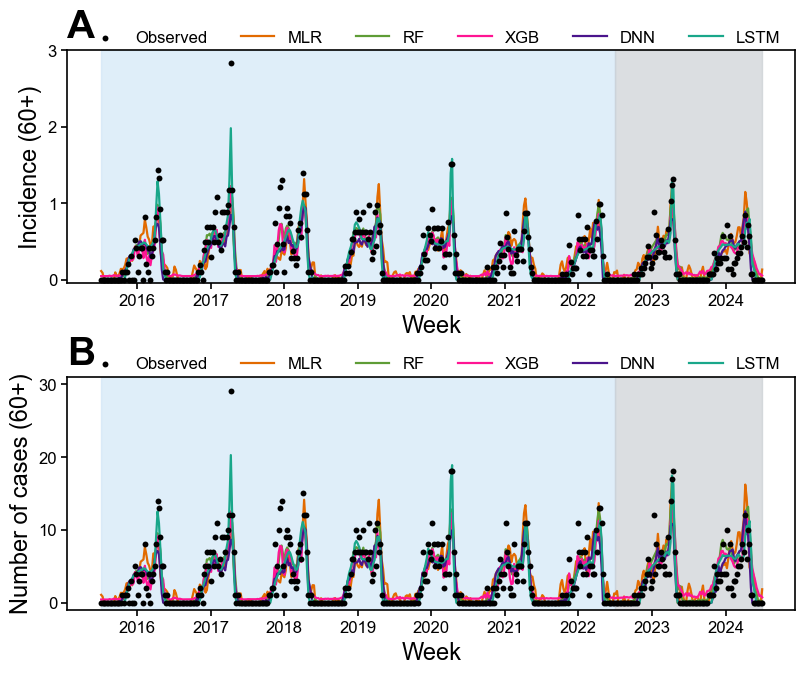

In [14]:
# ============================================================
# 0) 기본 설정
# ============================================================

save_name = "Supplementary1.tiff"
save_path = os.path.join(figure_dir, save_name)


# ============================================================
# 1) 파일 경로
# ============================================================
train_case_path = os.path.join(base_path, "best_valid_result_train.xlsx")
test_case_path = os.path.join(base_path, "best_valid_result_test.xlsx")

train_inc_path = os.path.join(base_path, "best_valid_result_train_incidence.xlsx")
test_inc_path = os.path.join(base_path, "best_valid_result_test_incidence.xlsx")

observed_path = os.path.join(base_path, "New_data11.xlsx")


# ============================================================
# 2) 색상 설정
#    실제 컬럼명은 LR 그대로 사용
#    그림 표시만 MLR로 변경
# ============================================================
model_colors = {
    "RF":   "#5E9C36",
    "LSTM": "#19A78A",
    "LR":   "#E26A00",
    "XGB":  "#FF1493",
    "DNN":  "#4A148C"
}

observed_color = "black"
train_bg = "#CFE5F7"
test_bg = "#C8CDD1"


# ============================================================
# 3) Year, Week 컬럼 정리 함수
# ============================================================
def normalize_year_week_columns(df):
    df = df.copy()

    df.columns = df.columns.astype(str).str.strip()

    rename_map = {}

    if "year" in df.columns:
        rename_map["year"] = "Year"

    if "week" in df.columns:
        rename_map["week"] = "Week"

    if rename_map:
        df = df.rename(columns=rename_map)

    return df


# ============================================================
# 4) 날짜 생성 함수
# ============================================================
def make_week_date(df, year_col="Year", week_col="Week"):
    df = df.copy()

    df = normalize_year_week_columns(df)

    if year_col not in df.columns:
        raise KeyError(
            f"{year_col} 컬럼이 없습니다. 현재 컬럼: {list(df.columns)}"
        )

    if week_col not in df.columns:
        raise KeyError(
            f"{week_col} 컬럼이 없습니다. 현재 컬럼: {list(df.columns)}"
        )

    df[year_col] = df[year_col].astype(int)
    df[week_col] = df[week_col].astype(int)

    date_str = (
        df[year_col].astype(str)
        + "-W"
        + df[week_col].astype(str).str.zfill(2)
        + "-1"
    )

    df["Date"] = pd.to_datetime(date_str, format="%G-W%V-%u", errors="coerce")

    if df["Date"].isna().any():
        df["Date"] = (
            pd.to_datetime(df[year_col].astype(str) + "-01-01")
            + pd.to_timedelta((df[week_col] - 1) * 7, unit="D")
        )

    return df


# ============================================================
# 5) 예측값 불러오기
#    incidence 파일처럼 Year, Week가 없는 경우
#    reference 파일에서 Year, Week를 붙임
# ============================================================
def load_pred_data(train_path, test_path, train_ref_path=None, test_ref_path=None):
    train_df = read_excel_cached(train_path)
    test_df = read_excel_cached(test_path)

    train_df = normalize_year_week_columns(train_df)
    test_df = normalize_year_week_columns(test_df)

    # --------------------------------------------------------
    # train 파일에 Year, Week가 없으면 reference train 파일에서 가져옴
    # --------------------------------------------------------
    if ("Year" not in train_df.columns) or ("Week" not in train_df.columns):

        if train_ref_path is None:
            raise KeyError(
                f"train 파일에 Year, Week 컬럼이 없습니다. 현재 컬럼: {list(train_df.columns)}"
            )

        train_ref = read_excel_cached(train_ref_path)
        train_ref = normalize_year_week_columns(train_ref)

        if ("Year" not in train_ref.columns) or ("Week" not in train_ref.columns):
            raise KeyError(
                f"train reference 파일에도 Year, Week 컬럼이 없습니다. 현재 컬럼: {list(train_ref.columns)}"
            )

        train_df = pd.concat(
            [
                train_ref[["Year", "Week"]].reset_index(drop=True),
                train_df.reset_index(drop=True)
            ],
            axis=1
        )

    # --------------------------------------------------------
    # test 파일에 Year, Week가 없으면 reference test 파일에서 가져옴
    # --------------------------------------------------------
    if ("Year" not in test_df.columns) or ("Week" not in test_df.columns):

        if test_ref_path is None:
            raise KeyError(
                f"test 파일에 Year, Week 컬럼이 없습니다. 현재 컬럼: {list(test_df.columns)}"
            )

        test_ref = read_excel_cached(test_ref_path)
        test_ref = normalize_year_week_columns(test_ref)

        if ("Year" not in test_ref.columns) or ("Week" not in test_ref.columns):
            raise KeyError(
                f"test reference 파일에도 Year, Week 컬럼이 없습니다. 현재 컬럼: {list(test_ref.columns)}"
            )

        test_df = pd.concat(
            [
                test_ref[["Year", "Week"]].reset_index(drop=True),
                test_df.reset_index(drop=True)
            ],
            axis=1
        )

    train_df = make_week_date(train_df)
    test_df = make_week_date(test_df)

    pred_df = pd.concat([train_df, test_df], ignore_index=True)
    pred_df = pred_df.sort_values(["Year", "Week"]).reset_index(drop=True)

    return pred_df


# ============================================================
# 6) 관측값 불러오기
# ============================================================
def load_observed_data(path):
    obs = read_excel_cached(path)

    obs = normalize_year_week_columns(obs)
    obs = make_week_date(obs)

    obs = obs[
        (obs["Year"] >= 2016) &
        (obs["Year"] <= 2024)
    ].copy()

    return obs


# ============================================================
# 7) x축 눈금: 매년 7월 위치에 연도만 표시
# ============================================================
def get_year_center_ticks(df):
    years = sorted(df["Year"].dropna().astype(int).unique())

    tick_dates = [
        pd.to_datetime(f"{year}-07-01")
        for year in years
    ]

    return tick_dates


# ============================================================
# 8) 축 스타일
# ============================================================
def style_axis(ax):
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    ax.tick_params(
        axis="both",
        labelsize=12,
        width=1.2,
        length=4,
        color="black"
    )


# ============================================================
# 9) 패널 그리기 함수
#    실제 LR 컬럼을 사용하되, 그림에는 MLR로 표시
# ============================================================
def plot_panel(
    ax,
    pred_df,
    obs_df,
    obs_col,
    panel_label,
    left_red_text,
    ylabel,
    ylim=None,
    yticks=None
):
    # --------------------------------------------------------
    # 관측값 병합
    # --------------------------------------------------------
    plot_df = pred_df.merge(
        obs_df[["Year", "Week", "Date", obs_col]],
        on=["Year", "Week", "Date"],
        how="left"
    )

    # --------------------------------------------------------
    # 배경 음영
    # --------------------------------------------------------
    train_start = pd.to_datetime("2016-01-01")
    train_end   = pd.to_datetime("2022-12-31")
    test_start  = pd.to_datetime("2023-01-01")
    test_end    = pd.to_datetime("2024-12-31")

    ax.axvspan(train_start, train_end, color=train_bg, alpha=0.65, zorder=0)
    ax.axvspan(test_start, test_end, color=test_bg, alpha=0.65, zorder=0)

    # --------------------------------------------------------
    # 모델 선 먼저 그림
    # 실제 컬럼명은 LR 그대로 사용
    # 범례 표시만 LR → MLR
    # 표시 순서: MLR, RF, XGB, DNN, LSTM
    # --------------------------------------------------------
    model_order = ["LR", "RF", "XGB", "DNN", "LSTM"]

    for model in model_order:
        if model in plot_df.columns:

            display_label = "MLR" if model == "LR" else model

            ax.plot(
                plot_df["Date"],
                plot_df[model],
                color=model_colors[model],
                linewidth=1.6,
                label=display_label,
                zorder=3
            )

    # --------------------------------------------------------
    # Observed 점 나중에 그림
    # --------------------------------------------------------
    ax.scatter(
        plot_df["Date"],
        plot_df[obs_col],
        color=observed_color,
        s=18,
        label="Observed",
        zorder=5,
        linewidths=0
    )

    # --------------------------------------------------------
    # 축 라벨
    # --------------------------------------------------------
    ax.set_ylabel(ylabel, fontsize=17)
    ax.set_xlabel("Week", fontsize=17)

    if ylim is not None:
        ax.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    # ========================================================
    # x축 눈금: 매년 7월 위치에 연도만 표시
    # ========================================================
    tick_dates = get_year_center_ticks(plot_df)

    ax.set_xticks(tick_dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")
        label.set_fontsize(11)

    # --------------------------------------------------------
    # 패널 문자
    # --------------------------------------------------------
    ax.text(
        0.0, 1.02, panel_label,
        transform=ax.transAxes,
        fontsize=28,
        fontweight="bold",
        va="bottom",
        ha="left"
    )

    # --------------------------------------------------------
    # 범례
    # 표시 순서에서도 LR 대신 MLR 사용
    # --------------------------------------------------------
    handles, labels = ax.get_legend_handles_labels()
    order = ["Observed", "MLR", "RF", "XGB", "DNN", "LSTM"]

    label_to_handle = dict(zip(labels, handles))
    ordered_handles = [label_to_handle[k] for k in order if k in label_to_handle]
    ordered_labels = [k for k in order if k in label_to_handle]

    ax.legend(
        ordered_handles,
        ordered_labels,
        loc="upper right",
        bbox_to_anchor=(1.00, 1.15),
        ncol=6,
        frameon=False,
        fontsize=12
    )

    style_axis(ax)


# ============================================================
# 10) 데이터 불러오기
# ============================================================
pred_case = load_pred_data(
    train_case_path,
    test_case_path
)

pred_inc = load_pred_data(
    train_inc_path,
    test_inc_path,
    train_ref_path=train_case_path,
    test_ref_path=test_case_path
)

obs_df = load_observed_data(observed_path)


# ============================================================
# 11) 그림 생성
# ============================================================
fig = plt.figure(figsize=(13, 8))

gs = fig.add_gridspec(
    2, 1,
    left=0.38,
    right=0.94,
    top=0.82,
    bottom=0.12,
    hspace=0.4
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[1, 0])


# ============================================================
# A: Incidence
# ============================================================
plot_panel(
    ax=axA,
    pred_df=pred_inc,
    obs_df=obs_df,
    obs_col="Incidence_60",
    panel_label="A",
    left_red_text="Incidence",
    ylabel="Incidence (60+)",
    ylim=(-0.05, 3.0),
    yticks=[0.0, 1.0, 2.0, 3.0]
)


# ============================================================
# B: Case
# ============================================================
plot_panel(
    ax=axB,
    pred_df=pred_case,
    obs_df=obs_df,
    obs_col="Cases_60",
    panel_label="B",
    left_red_text="Case",
    ylabel="Number of cases (60+)",
    ylim=(-1, 31),
    yticks=[0, 10, 20, 30]
)


# ============================================================
# 12) 저장 및 출력
# ============================================================
if SAVE_FIG:
    os.makedirs(figure_dir, exist_ok=True)

    plt.savefig(
        save_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    print(f"저장 완료: {save_path}")

plt.show()

## Supplementary Figure 2. Bootstrap train/test results by model

저장 완료: C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Supplementary2.tiff


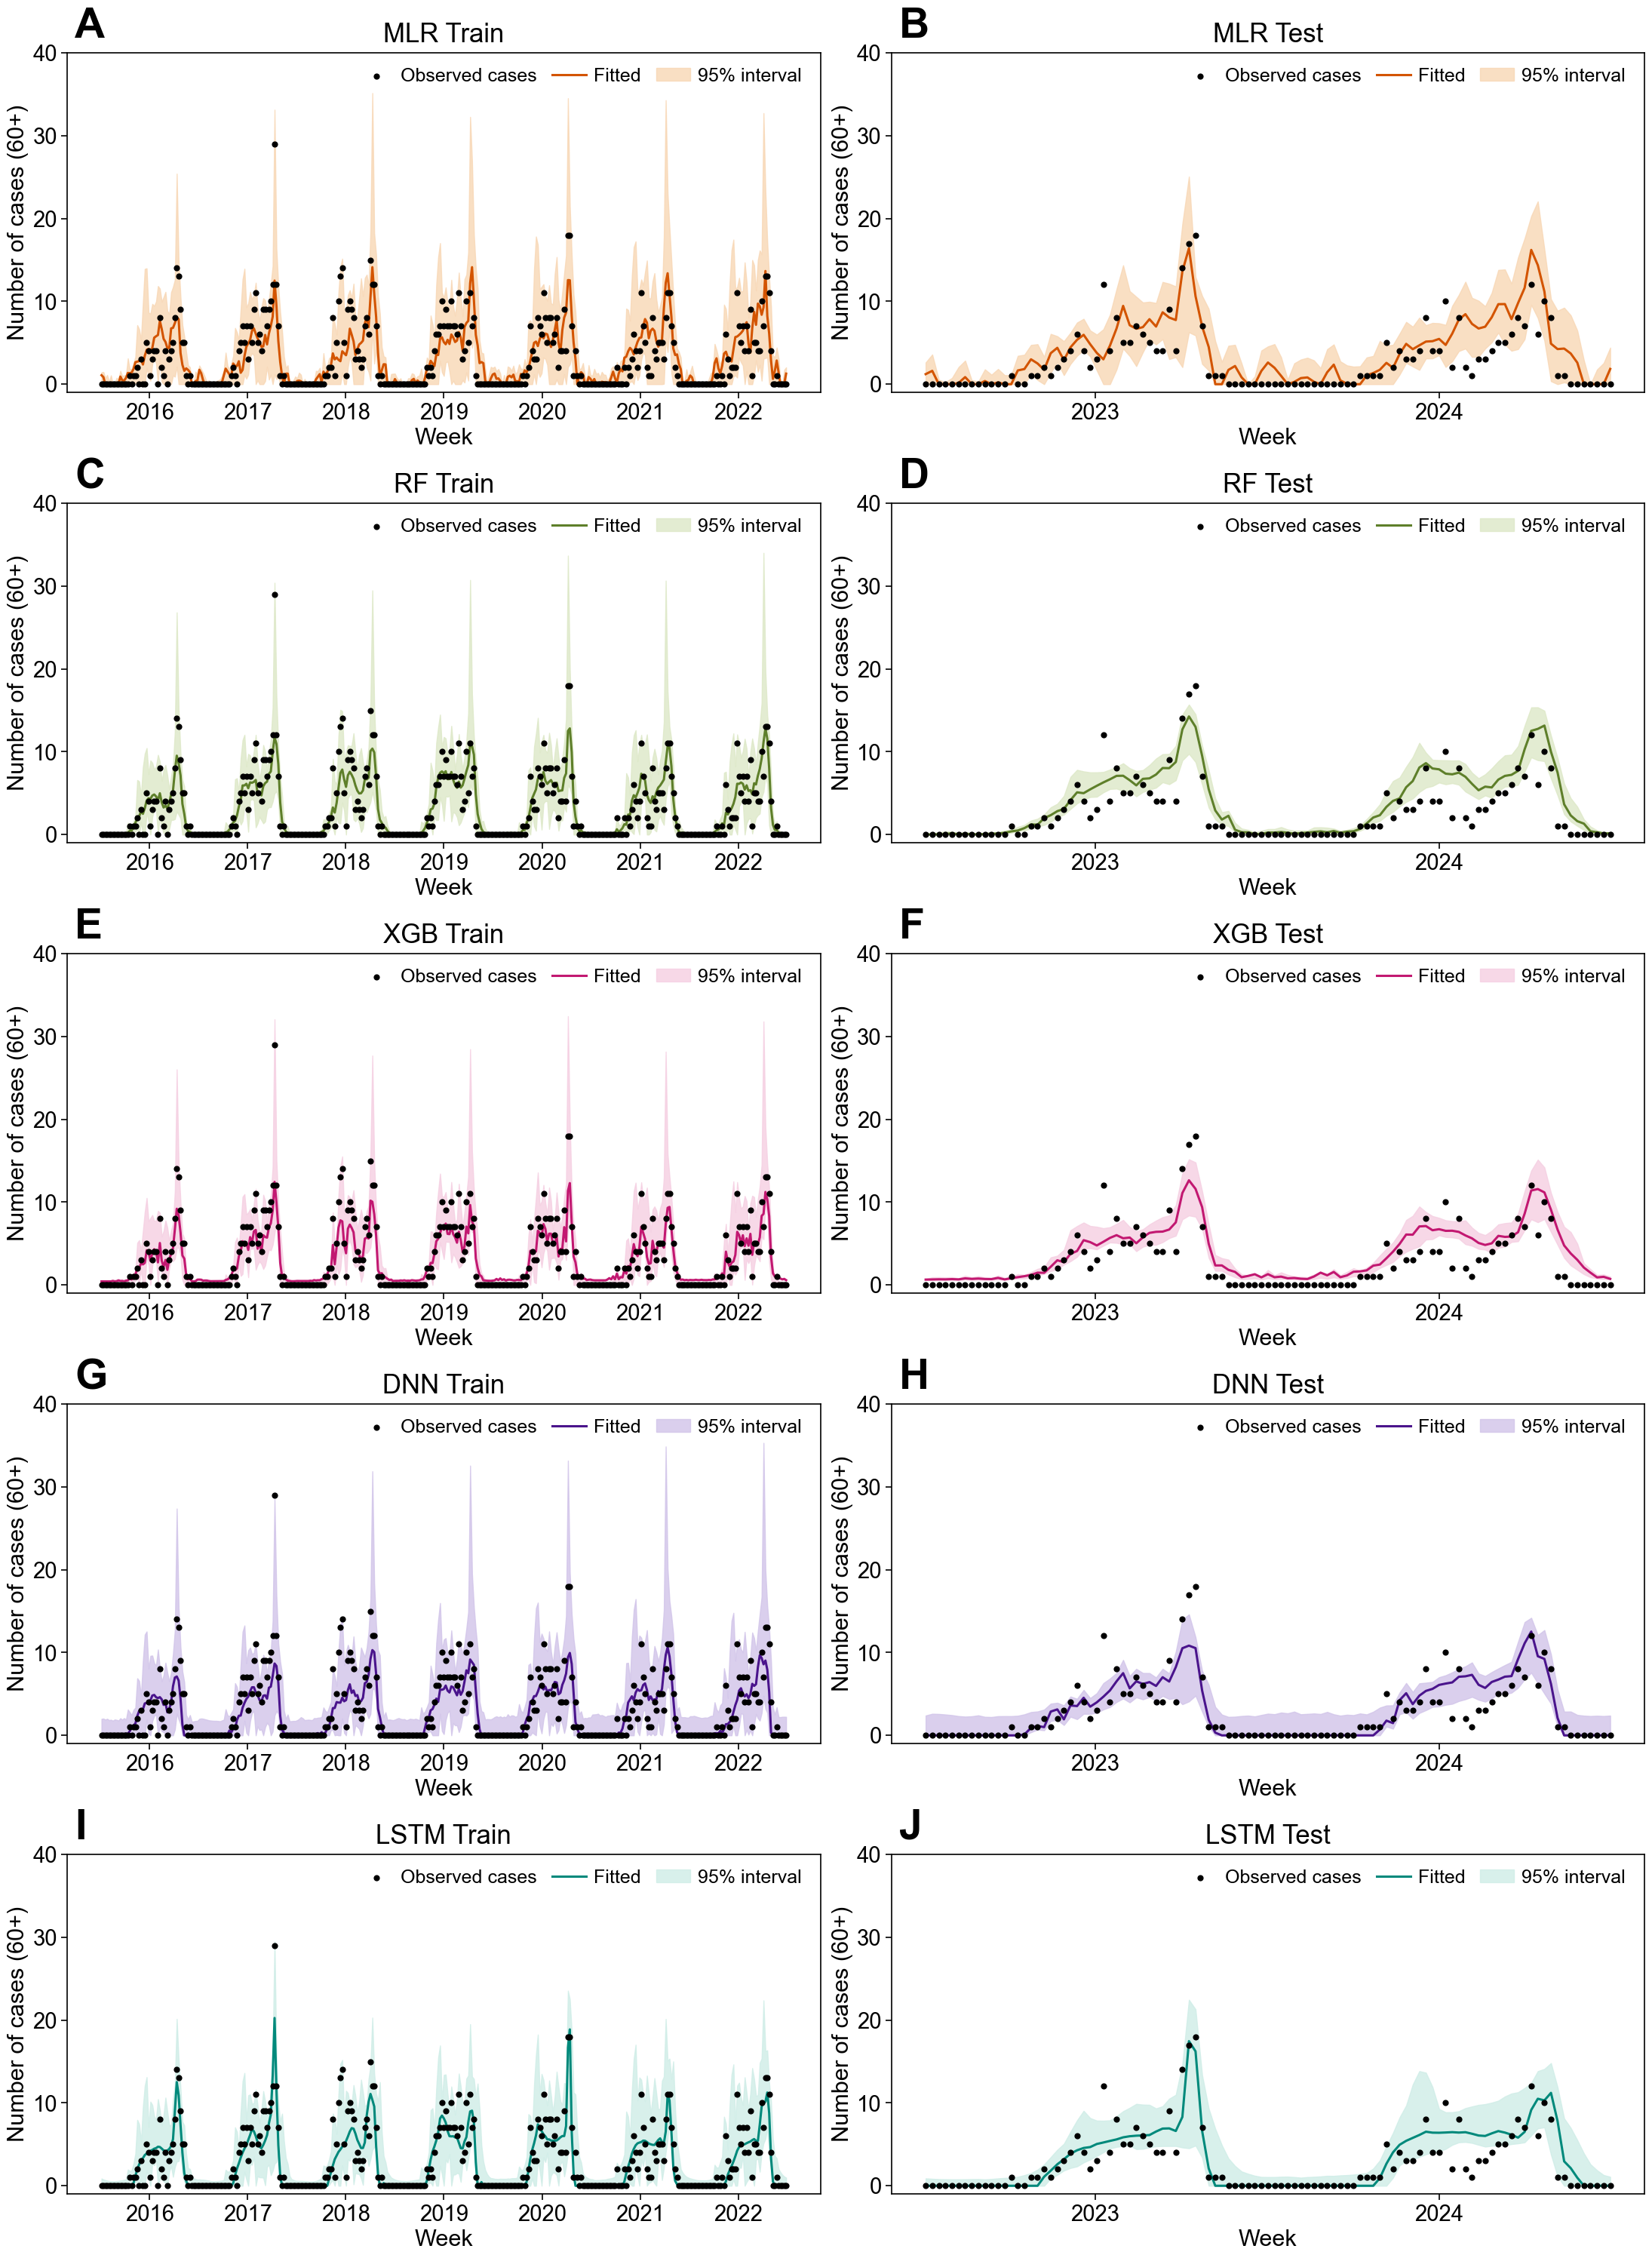

In [15]:
# ============================================================
# 0) 기본 설정
# ============================================================

save_name = "Supplementary2.tiff"
save_path = os.path.join(figure_dir, save_name)

observed_file = os.path.join(base_path, "New_data11.xlsx")


# ============================================================
# 0-1) 글자 크기 설정
# ============================================================
TITLE_SIZE = 25
PANEL_LABEL_SIZE = 40
XLABEL_SIZE = 22
YLABEL_SIZE = 22
XTICK_SIZE = 21
YTICK_SIZE = 21
LEGEND_SIZE = 18


# ============================================================
# 1) 파일 경로
#    실제 파일명은 LR 그대로 사용
# ============================================================
files = {
    "LR": {
        "train": os.path.join(base_path, "LR_CI_train_result.xlsx"),
        "test": os.path.join(base_path, "LR_CI_test_result.xlsx"),
    },
    "RF": {
        "train": os.path.join(base_path, "RF_CI_train_result.xlsx"),
        "test": os.path.join(base_path, "RF_CI_test_result.xlsx"),
    },
    "XGB": {
        "train": os.path.join(base_path, "XGB_CI_train_result.xlsx"),
        "test": os.path.join(base_path, "XGB_CI_test_result.xlsx"),
    },
    "DNN": {
        "train": os.path.join(base_path, "DNN_CI_train_result.xlsx"),
        "test": os.path.join(base_path, "DNN_CI_test_result.xlsx"),
    },
    "LSTM": {
        "train": os.path.join(base_path, "LSTM_CI_train_result.xlsx"),
        "test": os.path.join(base_path, "LSTM_CI_test_result.xlsx"),
    },
}


# ============================================================
# 2) 모델 색상
#    실제 key는 LR 그대로 사용
# ============================================================
model_styles = {
    "LR": {
        "best": "#D35400",
        "ci":   "#F8D7B5"
    },
    "RF": {
        "best": "#5E7F2A",
        "ci":   "#DDE8C7"
    },
    "XGB": {
        "best": "#C21871",
        "ci":   "#F5CFE2"
    },
    "DNN": {
        "best": "#4A148C",
        "ci":   "#D1C4E9"
    },
    "LSTM": {
        "best": "#00897B",
        "ci":   "#CFEDE7"
    },
}


# ============================================================
# 3) 보조 함수
# ============================================================
def make_week_date(df, year_col="Year", week_col="Week"):
    df = df.copy()
    df[year_col] = df[year_col].astype(int)
    df[week_col] = df[week_col].astype(int)

    date_str = (
        df[year_col].astype(str)
        + "-W"
        + df[week_col].astype(str).str.zfill(2)
        + "-1"
    )

    df["Date"] = pd.to_datetime(date_str, format="%G-W%V-%u", errors="coerce")

    if df["Date"].isna().any():
        df["Date"] = (
            pd.to_datetime(df[year_col].astype(str) + "-01-01")
            + pd.to_timedelta((df[week_col] - 1) * 7, unit="D")
        )

    return df


def load_observed_data(path):
    obs = read_excel_cached(path)
    obs = obs.copy()

    if "Cases_60" not in obs.columns:
        raise ValueError("observed_file에 'Cases_60' 컬럼이 없습니다.")

    if "Year" not in obs.columns or "Week" not in obs.columns:
        raise ValueError("observed_file에 'Year', 'Week' 컬럼이 필요합니다.")

    obs = make_week_date(obs)
    obs = obs[["Year", "Week", "Date", "Cases_60"]].copy()
    obs = obs.rename(columns={"Cases_60": "Actual"})

    return obs


def load_ci_data(ci_path, observed_df):
    df = read_excel_cached(ci_path)
    df = make_week_date(df)

    # Bootstrap median 제거: p50은 사용하지 않음
    for col in ["mean", "p025", "p975", "best"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0)

    df = df.merge(
        observed_df[["Year", "Week", "Actual"]],
        on=["Year", "Week"],
        how="left"
    )

    return df


def get_july_year_ticks(df):
    """
    x축 눈금을 각 연도 7월 1일 위치에 표시하고,
    눈금 라벨은 2016, 2017처럼 연도만 표시
    """
    years = sorted(df["Year"].dropna().astype(int).unique())

    tick_dates = [
        pd.Timestamp(year=int(year), month=7, day=1)
        for year in years
    ]

    tick_labels = [
        str(int(year))
        for year in years
    ]

    return tick_dates, tick_labels


def style_axis(ax):
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    ax.set_facecolor("white")

    ax.tick_params(
        axis="x",
        labelsize=XTICK_SIZE,
        width=1.2,
        length=6,
        color="black"
    )

    ax.tick_params(
        axis="y",
        labelsize=YTICK_SIZE,
        width=1.2,
        length=6,
        color="black"
    )


def plot_one_panel(ax, df, model_name, mode_name, panel_label=None):
    style = model_styles[model_name]
    x = df["Date"]

    # ========================================================
    # 표시 이름만 변경: LR → MLR
    # 실제 데이터/파일/색상 key는 LR 그대로 사용
    # ========================================================
    display_model_name = "MLR" if model_name == "LR" else model_name

    # ========================================================
    # 1) 95% CI 먼저 그림
    # ========================================================
    ax.fill_between(
        x,
        df["p025"],
        df["p975"],
        color=style["ci"],
        alpha=0.8,
        label="95% interval",
        zorder=1
    )

    # ========================================================
    # 2) Fitted: 실선
    # ========================================================
    ax.plot(
        x,
        df["best"],
        color=style["best"],
        linewidth=2.2,
        linestyle="-",
        label="Fitted",
        zorder=4
    )

    # ========================================================
    # 3) Observed cases 점을 가장 위에 그림
    # ========================================================
    ax.scatter(
        x,
        df["Actual"],
        color="black",
        s=24,
        label="Observed cases",
        zorder=5
    )

    # ========================================================
    # subplot 제목
    # LR인 경우 제목만 MLR Train / MLR Test로 표시
    # ========================================================
    ax.set_title(
        f"{display_model_name} {mode_name}",
        fontsize=TITLE_SIZE,
        pad=10
    )

    # 패널 라벨 A~J
    if panel_label is not None:
        ax.text(
            0.01, 1.02, panel_label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE,
            fontweight="bold",
            ha="left",
            va="bottom"
        )

    # 축 라벨
    ax.set_ylabel(
        "Number of cases (60+)",
        fontsize=YLABEL_SIZE,
    )

    ax.set_xlabel(
        "Week",
        fontsize=XLABEL_SIZE
    )

    # ========================================================
    # x축 눈금: 각 연도 7월 위치에 연도만 표시
    # ========================================================
    tick_dates, tick_labels = get_july_year_ticks(df)

    ax.set_xticks(tick_dates)
    ax.set_xticklabels(tick_labels)

    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")
        label.set_fontsize(XTICK_SIZE)

    # y축 범위 및 눈금 통일
    ax.set_ylim(-1, 40)
    ax.set_yticks([0, 10, 20, 30, 40])

    for label in ax.get_yticklabels():
        label.set_fontsize(YTICK_SIZE)

    # ========================================================
    # 범례 순서: Bootstrap median 제거
    # ========================================================
    handles, labels = ax.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_labels = [
        "Observed cases",
        "Fitted",
        "95% interval"
    ]

    ordered_handles = [
        label_to_handle[l]
        for l in ordered_labels
        if l in label_to_handle
    ]

    ax.legend(
        ordered_handles,
        ordered_labels,
        loc="upper right",
        bbox_to_anchor=(0.99, 0.99),
        ncol=3,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.8,
        handletextpad=0.4,
        columnspacing=0.8,
        borderaxespad=0.2
    )

    style_axis(ax)


# ============================================================
# 4) 데이터 불러오기
# ============================================================
observed_df = load_observed_data(observed_file)

model_order = ["LR", "RF", "XGB", "DNN", "LSTM"]
panel_labels = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]


# ============================================================
# 5) 그림 생성
# ============================================================
fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(22, 30)
)

label_idx = 0

for i, model_name in enumerate(model_order):
    train_df = load_ci_data(files[model_name]["train"], observed_df)
    test_df = load_ci_data(files[model_name]["test"], observed_df)

    plot_one_panel(
        axes[i, 0],
        train_df,
        model_name=model_name,
        mode_name="Train",
        panel_label=panel_labels[label_idx]
    )
    label_idx += 1

    plot_one_panel(
        axes[i, 1],
        test_df,
        model_name=model_name,
        mode_name="Test",
        panel_label=panel_labels[label_idx]
    )
    label_idx += 1


plt.subplots_adjust(hspace=0.7, wspace=0.12)

plt.tight_layout()


# ============================================================
# 6) 저장 및 출력
# ============================================================
if SAVE_FIG:
    os.makedirs(figure_dir, exist_ok=True)

    plt.savefig(
        save_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    print(f"저장 완료: {save_path}")

plt.show()

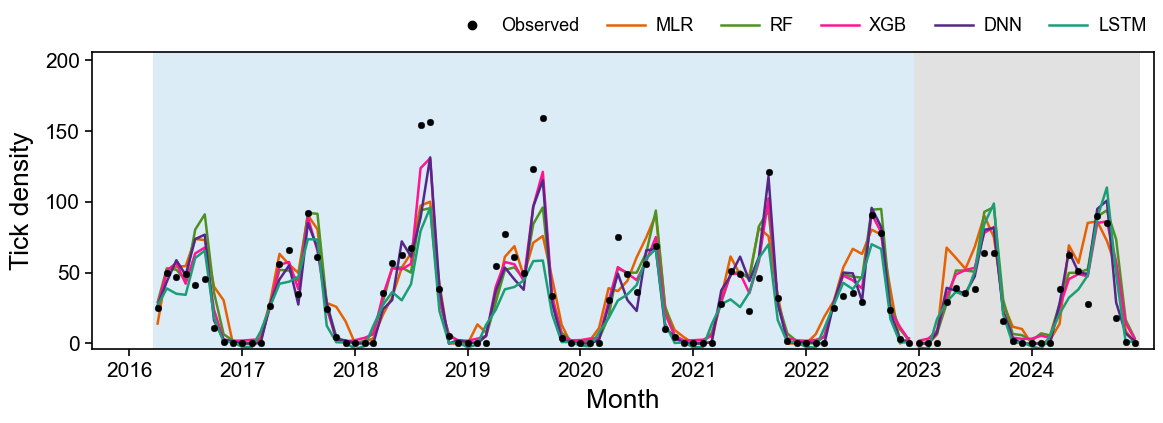

그림 저장 완료
C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Supplementary3.tiff


In [16]:
# ============================================================
# Supplementary Figure 3
# Monthly observed and predicted tick density
#
# 범례 순서:
# Observed, MLR, RF, XGB, DNN, LSTM
#
# Train: 2016-04 ~ 2022-12
# Test : 2023-01 ~ 2024-12
#
# 저장 위치:
# C:\Users\Main\Dropbox\CNN_LSTM\수정코드
# \Figure_1\Supplementary3.tiff
# ============================================================


# ============================================================
# 0) 라이브러리
# ============================================================



# ============================================================
# 1) 파일 경로
# ============================================================

base_path = r"C:\Users\Main\Dropbox\CNN_LSTM\수정코드"
figure_dir = os.path.join(base_path, "Figure_2")

train_path = os.path.join(
    base_path,
    "Tick_pred_train.xlsx"
)

test_path = os.path.join(
    base_path,
    "Tick_pred_test.xlsx"
)

observed_path = os.path.join(
    base_path,
    "SFTS 진드기 밀도.xlsx"
)

# 저장 폴더가 없으면 생성
os.makedirs(
    figure_dir,
    exist_ok=True
)

save_path = os.path.join(
    figure_dir,
    "Supplementary3.tiff"
)


# ============================================================
# 2) 기존 그림 객체 제거
# ============================================================

plt.close("all")


# ============================================================
# 3) 그림 기본 설정
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False

FIG_WIDTH = 12
FIG_HEIGHT = 4.8

AXIS_LABEL_SIZE = 19
TICK_SIZE = 15
LEGEND_SIZE = 13

LINE_WIDTH = 1.8
OBSERVED_SIZE = 23


# 참고 그림과 동일한 모델 색상
COLORS = {
    "MLR": "#E66101",   # 주황색
    "RF": "#4D9221",    # 초록색
    "XGB": "#FF1493",   # 분홍색
    "DNN": "#542788",   # 보라색
    "LSTM": "#1B9E77"   # 청록색
}

# Train/Test 배경색
TRAIN_BACKGROUND = "#DCECF7"
TEST_BACKGROUND = "#E1E1E1"


# ============================================================
# 4) 파일 존재 여부 확인
# ============================================================

required_files = {
    "Train prediction": train_path,
    "Test prediction": test_path,
    "Observed tick density": observed_path
}

for file_name, file_path in required_files.items():

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"{file_name} 파일을 찾을 수 없습니다.\n"
            f"확인 경로: {file_path}"
        )


# ============================================================
# 5) 데이터 불러오기
# ============================================================

train_df = pd.read_excel(
    train_path,
    engine="openpyxl"
)

test_df = pd.read_excel(
    test_path,
    engine="openpyxl"
)

observed_df = pd.read_excel(
    observed_path,
    engine="openpyxl"
)


# ============================================================
# 6) 컬럼명 정리
# ============================================================

train_df.columns = (
    train_df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

test_df.columns = (
    test_df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

observed_df.columns = (
    observed_df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


# LR은 그림에서 MLR로 표시
rename_columns = {
    "lr": "MLR",
    "mlr": "MLR",
    "rf": "RF",
    "xgb": "XGB",
    "dnn": "DNN",
    "lstm": "LSTM"
}

train_df = train_df.rename(
    columns=rename_columns
)

test_df = test_df.rename(
    columns=rename_columns
)


# ============================================================
# 7) 필요한 컬럼 확인
# ============================================================

required_models = [
    "MLR",
    "RF",
    "XGB",
    "DNN",
    "LSTM"
]

for model in required_models:

    if model not in train_df.columns:

        raise ValueError(
            f"Train 데이터에 '{model}' 컬럼이 없습니다.\n"
            f"현재 컬럼: {train_df.columns.tolist()}"
        )

    if model not in test_df.columns:

        raise ValueError(
            f"Test 데이터에 '{model}' 컬럼이 없습니다.\n"
            f"현재 컬럼: {test_df.columns.tolist()}"
        )


required_observed_columns = [
    "year",
    "month",
    "density"
]

for column in required_observed_columns:

    if column not in observed_df.columns:

        raise ValueError(
            f"관측자료에 '{column}' 컬럼이 없습니다.\n"
            f"현재 컬럼: {observed_df.columns.tolist()}"
        )


# ============================================================
# 8) 숫자형으로 변환
# ============================================================

for model in required_models:

    train_df[model] = pd.to_numeric(
        train_df[model],
        errors="coerce"
    )

    test_df[model] = pd.to_numeric(
        test_df[model],
        errors="coerce"
    )


observed_df["year"] = pd.to_numeric(
    observed_df["year"],
    errors="coerce"
)

observed_df["month"] = pd.to_numeric(
    observed_df["month"],
    errors="coerce"
)

observed_df["density"] = pd.to_numeric(
    observed_df["density"],
    errors="coerce"
)


observed_df = observed_df.dropna(
    subset=[
        "year",
        "month",
        "density"
    ]
).copy()


# ============================================================
# 9) 날짜 생성
# ============================================================

# 관측자료 날짜
observed_df["date"] = pd.to_datetime(
    {
        "year": observed_df["year"].astype(int),
        "month": observed_df["month"].astype(int),
        "day": 1
    }
)

observed_df = (
    observed_df
    .sort_values("date")
    .reset_index(drop=True)
)


# Train 기간: 2016-04부터 시작
train_start = pd.Timestamp("2016-04-01")

train_df["date"] = pd.date_range(
    start=train_start,
    periods=len(train_df),
    freq="MS"
)


# Test 기간: Train 종료 다음 달부터 시작
test_start = (
    train_df["date"].iloc[-1]
    + pd.offsets.MonthBegin(1)
)

test_df["date"] = pd.date_range(
    start=test_start,
    periods=len(test_df),
    freq="MS"
)


# ============================================================
# 10) 관측자료 분석기간 선택
# ============================================================

analysis_start = train_df["date"].min()
analysis_end = test_df["date"].max()

observed_plot = observed_df[
    (observed_df["date"] >= analysis_start)
    &
    (observed_df["date"] <= analysis_end)
].copy()

observed_plot = (
    observed_plot
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 11) 데이터 길이 확인
# ============================================================

expected_length = (
    len(train_df)
    + len(test_df)
)

if len(observed_plot) != expected_length:

    raise ValueError(
        "\n관측자료와 예측자료의 길이가 일치하지 않습니다.\n"
        f"관측자료 길이: {len(observed_plot)}\n"
        f"Train 길이: {len(train_df)}\n"
        f"Test 길이: {len(test_df)}\n"
        f"Train + Test 길이: {expected_length}\n"
        f"분석기간: "
        f"{analysis_start:%Y-%m} ~ {analysis_end:%Y-%m}"
    )


# ============================================================
# 12) 그림 생성
# ============================================================

fig, ax = plt.subplots(
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    constrained_layout=False
)


# ============================================================
# 13) Train/Test 배경 영역
# ============================================================

# 전체 축 범위에는 양쪽 여백을 주고,
# 색상 배경은 실제 Train/Test 기간에만 표시
train_left = (
    train_df["date"].iloc[0]
    - pd.DateOffset(days=15)
)

train_right = (
    train_df["date"].iloc[-1]
    + pd.DateOffset(days=15)
)

test_left = (
    test_df["date"].iloc[0]
    - pd.DateOffset(days=15)
)

test_right = (
    test_df["date"].iloc[-1]
    + pd.DateOffset(days=15)
)


ax.axvspan(
    train_left,
    train_right,
    facecolor=TRAIN_BACKGROUND,
    edgecolor="none",
    alpha=1.0,
    zorder=0
)

ax.axvspan(
    test_left,
    test_right,
    facecolor=TEST_BACKGROUND,
    edgecolor="none",
    alpha=1.0,
    zorder=0
)


# ============================================================
# 14) 모델별 예측값
# ============================================================

for model in required_models:

    # Train 예측값
    ax.plot(
        train_df["date"],
        train_df[model],
        color=COLORS[model],
        linewidth=LINE_WIDTH,
        solid_capstyle="round",
        zorder=2
    )

    # Test 예측값
    ax.plot(
        test_df["date"],
        test_df[model],
        color=COLORS[model],
        linewidth=LINE_WIDTH,
        solid_capstyle="round",
        zorder=2
    )


# ============================================================
# 15) 관측값
# ============================================================

ax.scatter(
    observed_plot["date"],
    observed_plot["density"],
    color="black",
    s=OBSERVED_SIZE,
    edgecolors="black",
    linewidths=0.3,
    zorder=5
)


# ============================================================
# 16) 축 제목
# ============================================================

ax.set_xlabel(
    "Month",
    fontsize=AXIS_LABEL_SIZE,
    labelpad=6
)

ax.set_ylabel(
    "Tick density",
    fontsize=AXIS_LABEL_SIZE,
    labelpad=8
)


# ============================================================
# 17) y축 범위
# ============================================================

all_values = [
    observed_plot["density"].to_numpy(
        dtype=float
    )
]

for model in required_models:

    all_values.append(
        train_df[model].to_numpy(
            dtype=float
        )
    )

    all_values.append(
        test_df[model].to_numpy(
            dtype=float
        )
    )


all_values = np.concatenate(all_values)

all_values = all_values[
    np.isfinite(all_values)
]


if len(all_values) == 0:

    raise ValueError(
        "그림에 사용할 유효한 숫자 데이터가 없습니다."
    )


y_max = max(
    200,
    np.nanmax(all_values)
)

y_upper = (
    np.ceil(y_max / 20)
    * 20
)


ax.set_ylim(
    bottom=-0.02 * y_upper,
    top=y_upper * 1.03
)


# ============================================================
# 18) x축 설정
# 참고 그림처럼 연도만 표시
# ============================================================

# 2016~2024년의 1월 위치를 연도 눈금으로 사용
year_ticks = pd.date_range(
    start="2016-01-01",
    end="2024-01-01",
    freq="YS"
)

ax.set_xticks(year_ticks)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)


# 연도 수평 표시
plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=TICK_SIZE
)


ax.tick_params(
    axis="x",
    width=1.2,
    length=5,
    direction="out",
    pad=4
)

ax.tick_params(
    axis="y",
    labelsize=TICK_SIZE,
    width=1.2,
    length=5,
    direction="out"
)


# 양쪽에 흰색 여백 추가
# 2016년 1월 이전부터 2025년 1월 직전까지 표시
ax.set_xlim(
    pd.Timestamp("2015-09-01"),
    pd.Timestamp("2025-01-31")
)


# ============================================================
# 19) 범례
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=6,
        label="Observed"
    ),

    Line2D(
        [0],
        [0],
        color=COLORS["MLR"],
        linewidth=LINE_WIDTH,
        label="MLR"
    ),

    Line2D(
        [0],
        [0],
        color=COLORS["RF"],
        linewidth=LINE_WIDTH,
        label="RF"
    ),

    Line2D(
        [0],
        [0],
        color=COLORS["XGB"],
        linewidth=LINE_WIDTH,
        label="XGB"
    ),

    Line2D(
        [0],
        [0],
        color=COLORS["DNN"],
        linewidth=LINE_WIDTH,
        label="DNN"
    ),

    Line2D(
        [0],
        [0],
        color=COLORS["LSTM"],
        linewidth=LINE_WIDTH,
        label="LSTM"
    )
]


# 범례의 마지막 항목 LSTM이 오른쪽 끝에 오도록 설정
ax.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.14),
    ncol=6,
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=2.1,
    handletextpad=0.6,
    columnspacing=1.5,
    borderaxespad=0
)


# ============================================================
# 20) 테두리 및 배경
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)


ax.grid(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")


# ============================================================
# 21) 여백 조정
# ============================================================

plt.subplots_adjust(
    left=0.10,
    right=0.985,
    bottom=0.20,
    top=0.82
)


# ============================================================
# 22) 그림 저장
# ============================================================

# 메모리 사용량을 줄이기 위해
# bbox_inches="tight"와 TIFF 압축 옵션은 사용하지 않음
fig.savefig(
    save_path,
    dpi=300,
    format="tiff",
    facecolor="white"
)


# ============================================================
# 23) 콘솔 출력 후 메모리 해제
# ============================================================

plt.show()

plt.close(fig)
plt.close("all")


print("그림 저장 완료")
print(save_path)

저장 완료
C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_2\Supplementary4.tiff


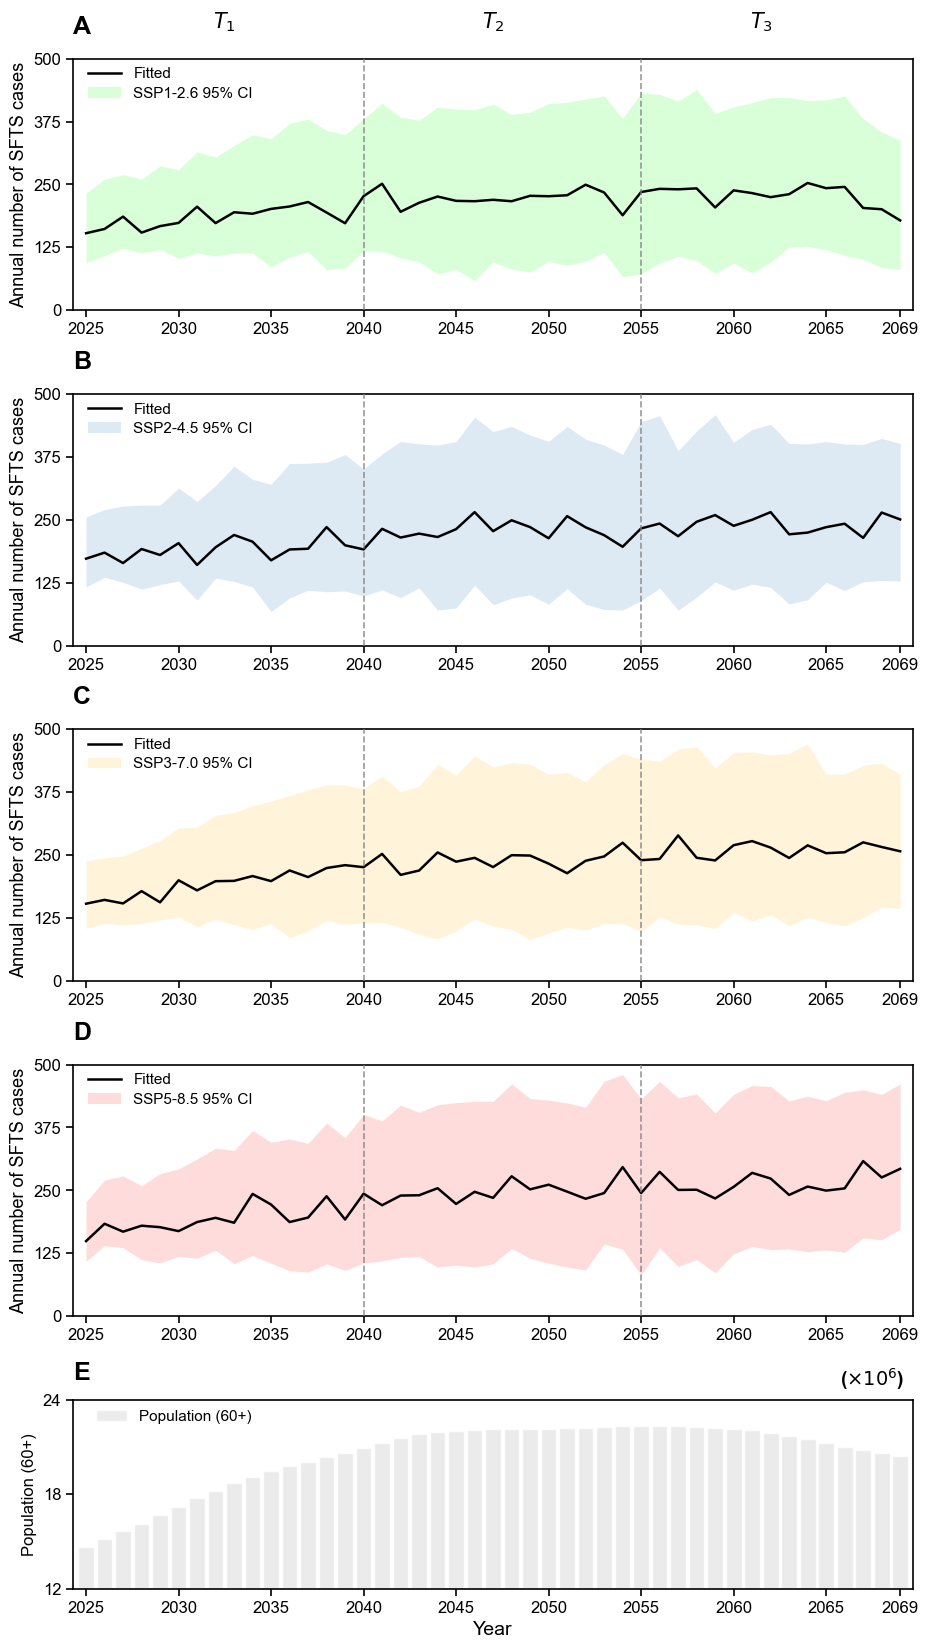

In [17]:
# ============================================================
# Supplementary Figure 4
# Annual SFTS cases under SSP scenarios and population aged 60+
# 95% CI + fitted line
#
# 저장 위치:
# C:\Users\Main\Dropbox\CNN_LSTM\수정코드\Figure_1
# ============================================================


# ============================================================
# 0) 라이브러리
# ============================================================




# ============================================================
# 1) 기존 그림 객체 제거
# ============================================================

plt.close("all")


# ============================================================
# 2) 기본 경로
# ============================================================

# raw string 마지막에 \를 넣지 않음
base_path = r"C:\Users\Main\Dropbox\CNN_LSTM\수정코드"

figure_dir = os.path.join(
    base_path,
    "Figure_2"
)

os.makedirs(
    figure_dir,
    exist_ok=True
)

save_name = "Supplementary4.tiff"

save_path = os.path.join(
    figure_dir,
    save_name
)


# ============================================================
# 3) 시각화 설정
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False

CI95_ALPHA = 0.15
POP_ALPHA = 0.8


# ============================================================
# 4) 파일 경로
# ============================================================

fitted_case_path = os.path.join(
    base_path,
    "fitted_prediction_annual_case.xlsx"
)

observed_file = os.path.join(
    base_path,
    "전국미래인구 데이터.xlsx"
)

scenario_files = {
    "SSP5-8.5": os.path.join(
        base_path,
        "forecasting_SSP585.xlsx"
    ),
    "SSP3-7.0": os.path.join(
        base_path,
        "forecasting_SSP370.xlsx"
    ),
    "SSP2-4.5": os.path.join(
        base_path,
        "forecasting_SSP245.xlsx"
    ),
    "SSP1-2.6": os.path.join(
        base_path,
        "forecasting_SSP126.xlsx"
    )
}


# ============================================================
# 5) 파일 존재 여부 확인
# ============================================================

required_files = {
    "Fitted annual cases": fitted_case_path,
    "Future population": observed_file,
    **scenario_files
}

for file_name, file_path in required_files.items():

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"{file_name} 파일을 찾을 수 없습니다.\n"
            f"확인 경로: {file_path}"
        )


# ============================================================
# 6) 엑셀 캐시 함수
# ============================================================

_excel_cache = {}


def read_excel_cached(file_path):
    """
    동일한 엑셀 파일을 반복해서 읽지 않도록
    메모리에 한 번만 불러오는 함수
    """

    if file_path not in _excel_cache:

        _excel_cache[file_path] = pd.read_excel(
            file_path,
            engine="openpyxl"
        )

    return _excel_cache[file_path].copy()


# ============================================================
# 7) Forecasting 파일 정리 함수
# ============================================================

def clean_forecasting_df_for_figure4(df):

    temp = df.copy()

    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
    )

    temp = temp.rename(
        columns={
            "year": "Year",
            "YEAR": "Year"
        }
    )

    required_cols = [
        "Year",
        "p025",
        "p50",
        "p975"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in temp.columns
    ]

    if missing_cols:

        raise KeyError(
            f"Forecasting 파일에 다음 컬럼이 없습니다: "
            f"{missing_cols}\n"
            f"현재 컬럼: {list(temp.columns)}"
        )

    temp["Year"] = pd.to_numeric(
        temp["Year"],
        errors="coerce"
    )

    for col in ["p025", "p50", "p975"]:

        temp[col] = pd.to_numeric(
            temp[col],
            errors="coerce"
        )

    temp = temp.dropna(
        subset=["Year"]
    ).copy()

    temp["Year"] = temp["Year"].astype(int)

    return temp


# ============================================================
# 8) Fitted annual case 파일 정리 함수
# ============================================================

def load_fitted_case_for_figure4(file_path):

    fitted_df = read_excel_cached(file_path)

    fitted_df.columns = (
        fitted_df.columns
        .astype(str)
        .str.strip()
    )

    fitted_df = fitted_df.rename(
        columns={
            "year": "Year",
            "YEAR": "Year"
        }
    )

    scenario_col_map = {
        "SSP1-2.6": "SSP126",
        "SSP2-4.5": "SSP245",
        "SSP3-7.0": "SSP370",
        "SSP5-8.5": "SSP585"
    }

    required_cols = [
        "Year",
        *scenario_col_map.values()
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in fitted_df.columns
    ]

    if missing_cols:

        raise KeyError(
            f"Fitted 파일에 다음 컬럼이 없습니다: "
            f"{missing_cols}\n"
            f"현재 컬럼: {list(fitted_df.columns)}"
        )

    fitted_df["Year"] = pd.to_numeric(
        fitted_df["Year"],
        errors="coerce"
    )

    fitted_df = fitted_df.dropna(
        subset=["Year"]
    ).copy()

    fitted_df["Year"] = fitted_df["Year"].astype(int)

    fitted_list = []

    for scenario, fitted_col in scenario_col_map.items():

        temp = fitted_df[
            ["Year", fitted_col]
        ].copy()

        temp = temp.rename(
            columns={
                fitted_col: "Fitted"
            }
        )

        temp["Fitted"] = pd.to_numeric(
            temp["Fitted"],
            errors="coerce"
        )

        temp["Scenario"] = scenario

        fitted_list.append(temp)

    fitted_long = pd.concat(
        fitted_list,
        ignore_index=True
    )

    return fitted_long


# ============================================================
# 9) Forecasting 및 fitted 데이터 결합
# ============================================================

fitted_long = load_fitted_case_for_figure4(
    fitted_case_path
)

df_list = []

for scenario, file_path in scenario_files.items():

    temp = read_excel_cached(file_path)

    temp = clean_forecasting_df_for_figure4(
        temp
    )

    temp["Scenario"] = scenario

    fitted_temp = fitted_long[
        fitted_long["Scenario"] == scenario
    ][
        ["Year", "Fitted"]
    ].copy()

    temp = pd.merge(
        temp,
        fitted_temp,
        on="Year",
        how="left"
    )

    df_list.append(temp)

all_df = pd.concat(
    df_list,
    ignore_index=True
)


# ============================================================
# 10) 2025–2069년 데이터 선택
# ============================================================

all_df = all_df[
    (all_df["Year"] >= 2025)
    &
    (all_df["Year"] <= 2069)
].copy()

year_order = list(
    range(2025, 2070)
)

x_ticks = list(
    range(2025, 2070, 5)
)

# 마지막 2069년 눈금 추가
if 2069 not in x_ticks:
    x_ticks.append(2069)


# ============================================================
# 11) 60세 이상 인구 데이터
# ============================================================

observed_df = read_excel_cached(
    observed_file
)

observed_df.columns = (
    observed_df.columns
    .astype(str)
    .str.strip()
)

observed_df = observed_df.rename(
    columns={
        "year": "Year",
        "YEAR": "Year"
    }
)

required_pop_cols = [
    "Year",
    "Population_60"
]

missing_pop_cols = [
    col
    for col in required_pop_cols
    if col not in observed_df.columns
]

if missing_pop_cols:

    raise KeyError(
        f"인구 파일에 다음 컬럼이 없습니다: "
        f"{missing_pop_cols}\n"
        f"현재 컬럼: {list(observed_df.columns)}"
    )

observed_df["Year"] = pd.to_numeric(
    observed_df["Year"],
    errors="coerce"
)

observed_df["Population_60"] = pd.to_numeric(
    observed_df["Population_60"],
    errors="coerce"
)

observed_df = observed_df.dropna(
    subset=[
        "Year",
        "Population_60"
    ]
).copy()

observed_df["Year"] = observed_df["Year"].astype(int)

pop_yearly = (
    observed_df
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        pop_mean=(
            "Population_60",
            "mean"
        )
    )
)

pop_yearly = pop_yearly[
    (pop_yearly["Year"] >= 2025)
    &
    (pop_yearly["Year"] <= 2069)
].copy()

pop_yearly["pop_mean_million"] = (
    pop_yearly["pop_mean"]
    / 1_000_000
)


# ============================================================
# 12) 색상 설정
# ============================================================

scenario_order = [
    "SSP1-2.6",
    "SSP2-4.5",
    "SSP3-7.0",
    "SSP5-8.5"
]

scenario_fill_colors = {
    "SSP1-2.6": "#00FF00",
    "SSP2-4.5": "#1F77B4",
    "SSP3-7.0": "#FFB000",
    "SSP5-8.5": "#FF1A1A"
}

population_color = "#E6E6E6"


# ============================================================
# 13) Figure layout
# ============================================================

fig = plt.figure(
    figsize=(10, 17)
)

gs = GridSpec(
    nrows=5,
    ncols=1,
    figure=fig,
    height_ratios=[
        1,
        1,
        1,
        1,
        0.75
    ],
    hspace=0.35
)

axes = [
    fig.add_subplot(gs[i, 0])
    for i in range(5)
]

axA, axB, axC, axD, axE = axes


# ============================================================
# 14) 공통 스타일 함수
# ============================================================

def set_black_spines(
    ax,
    linewidth=1.2
):

    for spine in ax.spines.values():

        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)


def apply_common_axis_style(ax):

    ax.grid(False)

    ax.tick_params(
        axis="both",
        labelsize=12,
        length=5,
        width=1.2,
        color="black",
        direction="out"
    )

    for label in ax.get_xticklabels():
        label.set_fontfamily("Arial")

    for label in ax.get_yticklabels():
        label.set_fontfamily("Arial")

    set_black_spines(ax)


# ============================================================
# 15) A–D: 시나리오별 fitted 값과 95% CI
# ============================================================

panel_labels = [
    "A",
    "B",
    "C",
    "D"
]

for ax, scenario, panel in zip(
    axes[:4],
    scenario_order,
    panel_labels
):

    temp = (
        all_df[
            all_df["Scenario"] == scenario
        ]
        .set_index("Year")
        .reindex(year_order)
        .reset_index()
    )

    years = pd.to_numeric(
        temp["Year"],
        errors="coerce"
    ).to_numpy(dtype=float)

    fitted_y = pd.to_numeric(
        temp["Fitted"],
        errors="coerce"
    ).to_numpy(dtype=float)

    low_95 = pd.to_numeric(
        temp["p025"],
        errors="coerce"
    ).to_numpy(dtype=float)

    high_95 = pd.to_numeric(
        temp["p975"],
        errors="coerce"
    ).to_numpy(dtype=float)

    # 95% CI
    ax.fill_between(
        years,
        low_95,
        high_95,
        color=scenario_fill_colors[scenario],
        alpha=CI95_ALPHA,
        linewidth=0,
        zorder=1
    )

    # Fitted line
    ax.plot(
        years,
        fitted_y,
        color="black",
        linewidth=1.8,
        zorder=3
    )

    # T1, T2, T3 구분선
    ax.axvline(
        x=2040,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
        zorder=4
    )

    ax.axvline(
        x=2055,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
        zorder=4
    )

    ax.set_ylim(
        0,
        500
    )

    ax.set_yticks(
        [0, 125, 250, 375, 500]
    )

    ax.set_ylabel(
        "Annual number of SFTS cases",
        fontsize=13,
        fontfamily="Arial"
    )

    ax.set_xticks(
        x_ticks
    )

    ax.set_xticklabels(
        [str(x) for x in x_ticks],
        rotation=0,
        fontsize=10,
        fontfamily="Arial"
    )

    # 패널 문자
    ax.text(
        0.0,
        1.08,
        panel,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        fontfamily="Arial",
        va="bottom",
        ha="left"
    )

    fitted_line = Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.8,
        label="Fitted"
    )

    ci95_patch = Patch(
        facecolor=scenario_fill_colors[scenario],
        edgecolor="none",
        alpha=CI95_ALPHA,
        label=f"{scenario} 95% CI"
    )

    legend = ax.legend(
        handles=[
            fitted_line,
            ci95_patch
        ],
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        frameon=False,
        fontsize=11,
        borderaxespad=0.0,
        ncol=1,
        handlelength=2.2,
        labelspacing=0.35
    )

    for text in legend.get_texts():

        text.set_color("black")
        text.set_fontfamily("Arial")

    apply_common_axis_style(ax)


# ============================================================
# 16) 상단 T1, T2, T3 라벨
# ============================================================

axA.text(
    0.18,
    1.10,
    r"$T_1$",
    transform=axA.transAxes,
    ha="center",
    va="bottom",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial"
)

axA.text(
    0.50,
    1.10,
    r"$T_2$",
    transform=axA.transAxes,
    ha="center",
    va="bottom",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial"
)

axA.text(
    0.82,
    1.10,
    r"$T_3$",
    transform=axA.transAxes,
    ha="center",
    va="bottom",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial"
)


# ============================================================
# 17) E: 60세 이상 인구
# ============================================================

pop_yearly = (
    pop_yearly
    .set_index("Year")
    .reindex(year_order)
    .reset_index()
)

pop_years = pd.to_numeric(
    pop_yearly["Year"],
    errors="coerce"
).to_numpy(dtype=float)

pop_y = pd.to_numeric(
    pop_yearly["pop_mean_million"],
    errors="coerce"
).to_numpy(dtype=float)

axE.bar(
    pop_years,
    pop_y,
    color=population_color,
    edgecolor="white",
    alpha=POP_ALPHA,
    width=0.85,
    zorder=1,
    label="Population (60+)"
)

axE.set_ylim(
    12,
    24
)

axE.set_yticks(
    [12, 18, 24]
)

axE.set_xticks(
    x_ticks
)

axE.set_xticklabels(
    [str(x) for x in x_ticks],
    rotation=0,
    fontsize=11,
    fontfamily="Arial"
)

axE.set_xlabel(
    "Year",
    fontsize=14,
    fontfamily="Arial"
)

axE.set_ylabel(
    "Population (60+)",
    fontsize=12,
    fontfamily="Arial"
)

axE.text(
    0.0,
    1.08,
    "E",
    transform=axE.transAxes,
    fontsize=18,
    fontweight="bold",
    fontfamily="Arial",
    va="bottom",
    ha="left"
)

axE.text(
    0.99,
    1.04,
    r"($\times 10^6$)",
    transform=axE.transAxes,
    fontsize=14,
    fontfamily="Arial",
    ha="right",
    fontweight="bold",
    va="bottom"
)

legend_e = axE.legend(
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=False,
    fontsize=11,
    borderaxespad=0.0
)

for text in legend_e.get_texts():
    text.set_fontfamily("Arial")

apply_common_axis_style(axE)


# ============================================================
# 18) 공통 x축 범위
# ============================================================

for ax in axes:

    ax.set_xlim(
        2024.3,
        2069.7
    )


# ============================================================
# 19) 그림 여백
# ============================================================

# tight_layout과 GridSpec hspace를 동시에 과도하게 사용하지 않음
plt.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.06,
    top=0.96,
    hspace=0.42
)


# ============================================================
# 20) 저장
# ============================================================

# 커널 메모리 부담을 줄이기 위해
# bbox_inches="tight"와 TIFF 압축 옵션을 사용하지 않음
fig.savefig(
    save_path,
    dpi=300,
    format="tiff",
    facecolor="white"
)

print("저장 완료")
print(save_path)


# ============================================================
# 21) 콘솔 출력 후 메모리 해제
# ============================================================

plt.show()

plt.close(fig)
plt.close("all")